In [1]:
#date: 2025-04-23
#author: Junjie Yang
#generate plots for the demographic analysis
#import peak area
# !pip install statannotations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [65]:
#==========2 demographic data processing
demogra_data = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_fmt.csv")
# Clean and classify demographic data
demogra_data['ga_weeks_mr'] = pd.to_numeric(demogra_data['ga_weeks_mr'], errors='coerce')
demogra_data['bmi_preprg_mr'] = pd.to_numeric(demogra_data['bmi_preprg_mr'], errors='coerce')
demogra_data['age_dlvry_mr'] = pd.to_numeric(demogra_data['age_dlvry_mr'], errors = 'coerce')

demogra_data['Terms'] = np.where(
    demogra_data['ga_weeks_mr'].isna(), 
    np.nan, 
    np.where(demogra_data['ga_weeks_mr'] < 37, 'preterm', 'full_term')
)

demogra_data['GDM_diag'] = demogra_data['gstdiab_mr'].map({
    "1, Yes": "GDM",
    "0, No": "Non-GDM",
    ".N, Not Noted in MR": np.nan,
    ".M, Missing": np.nan
})

demogra_data['Edu'] = demogra_data['edu_m_pre_cv'].map({
    "5, Graduate Degree": "Post_grad",
    "4, Bachelor's Degree": "College",
    "3, Some College or AA Degree": "College",
    "1, <High School": "Highschool/less",
    "2, HS Degree or GED": "Highschool/less",
    ".": np.nan,
    "": np.nan
})

demogra_data['Race'] = demogra_data['race_m_cv'].map({
    '1, White': 'NH-White',
    '2, Black or African American': 'NH-Black',
    '3, Asian': 'NH-Asian',
    '4, Native Hawaiian or Other Pacific Islander': 'other',
    '5, American Indian or Alaska Native': 'other',
    '6, More than 1 race': 'other',
    '-8, Unknown, Not Reported or Other': 'other'
    # 'hispanic': 'Latina'
})

demogra_data['Race_hispanic'] = demogra_data['hispanic_m_cv'].map({
    '0, No': 'Non-Latina',
    '1, Yes': 'Latina',
    'M': np.nan
})

# demogra_data['Nativity'] = demogra_data['usborn_m_cv'].map({
#     '1, US Born': 'US',
#     '0, Foreign Born': 'other',
#     '.': 'other'
# })

demogra_data['Smoke'] = demogra_data['smoke_cv'].map({
    '2, Former smoker': 'former-smoke',
    '1, Never smoked': 'non-smoke',
    '3, Current smoker': 'current-smoke',
    '.': np.nan
})

demogra_data['hypertension'] = demogra_data['htn_prg_mr'].map({
    '1, Yes': 'hypertension',
    '0, No': 'non-hypertension',
    '.M, Missing': np.nan,
    '.N, Not Noted in MR': np.nan
})

demogra_data['preclmps_mr'] = demogra_data['preclmps_mr'].map({
    '1, Yes': 'preclampsia',
    '0, No': 'non-preclampsia',
    '.M, Missing': np.nan,
    '.N, Not Noted in MR': np.nan
})

demogra_data['BMI'] = demogra_data['bmi_preprg_mr']

demogra_data['hospital_del'] = demogra_data['preclmps_mr'].map({
    '1, SFGH': 'SFGH',
    '2, Mission Bay': 'MB',
    '3, Elsewhere': 'other',
    'M': np.nan,
    'N': np.nan
})


# Convert ppt_id to string and reorder columns
demogra_data['ppt_id'] = demogra_data['ppt_id'].astype(str)
# cols = ['ppt_id', 'Terms', 'GDM_diag', 'Edu','hypertension','preclmps_mr'] + [col for col in demogra_data.columns if col not in ['ppt_id', 'Terms', 'GDM_diag', 'Edu']]
cols = ['ppt_id', 'Terms', 'GDM_diag', 'Edu','hypertension','preclmps_mr','Race','age_dlvry_mr'] 
demogra_data = demogra_data[cols]

# Print dimensions
print(demogra_data[demogra_data['Terms'] == 'preterm'].shape)
print(demogra_data[demogra_data['Terms'] == 'full_term'].shape)

(65, 8)
(671, 8)


In [ ]:
#extract BC data from netargeted and postargeted
pos_peak_path = r'D:\UCSF_postdoc_topic\REVEAL_first_400\MSDIAL_processed_results_200-400\pos_combat_batch_corrected.csv'    #DF >= 65
pos_peak_area = pd.read_csv(pos_peak_path, index_col=0)
# ========== 3. Process Peak Area ==========
pos_data = pos_peak_area.iloc[:, 1:].copy()
clean_names = pos_data.columns.str.extract(r'BH(\d{5})')[0]
pos_data.columns = clean_names
pos_data = pos_data.apply(pd.to_numeric, errors='coerce')

# Average replicates
pos_avg = pos_data.groupby(level=0, axis=1).mean()

# Rename columns
sample_name = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_sample_name_positive_with_participantID.csv")
sample_ids = sample_name['Participant_ID'].dropna().astype(int).unique()
sample_ids = sample_ids.astype(str).tolist()
num_sample_cols = pos_avg.shape[1]
pos_avg.columns = list(sample_ids[:num_sample_cols]) 
#set the index as column
pos_avg['peak_id'] = pos_avg.index

# Log2 transform and impute
cols = [c for c in pos_avg.columns if c != 'peak_id']
pos_avg[cols] = np.log10(pos_avg[cols])
pos_avg[cols] = pos_avg[cols].apply(
    lambda row: row.fillna(row.min()) if not row.isna().all() else row, axis=1
)

# --- 1. Load and Process QA_compoundlist ---
QA_compoundlist = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_matched_detectionfrequency.csv")
# Convert to float, format strictly to 4 and 3 decimal places, and combine
QA_compoundlist['std_peak_id'] = (
    QA_compoundlist['Average Mz'].astype(str) + "_" +
    QA_compoundlist['Average Rt(min)'].astype(str)
)
# print(f'number of the QA compounds found by exact mass search: {len(QA_compoundlist['DTXSID'].to_list().unique())}')

qa_target_ids_highfreq = QA_compoundlist[QA_compoundlist['Detection frequency'] >= 0.65]
# 2. Ensure both columns are strings and strip any hidden accidental spaces
qa_target_ids_highfreq = qa_target_ids_highfreq['feature_id'].astype(str).str.strip()
pos_avg['peak_id'] = pos_avg['peak_id'].astype(str).str.strip()

# 3. Filter pos_avg using the original feature_id
pos_avg_selected = pos_avg[pos_avg['peak_id'].isin(qa_target_ids_highfreq)]

print("Original pos_avg shape:", pos_avg.shape)
print("Selected pos_avg shape:", pos_avg_selected.shape)

QA_candidates = QA_compoundlist['DTXSID'].to_list()
print(f'number of unique candidate matches:{len(QA_candidates)}')

C:\Users\yangj\AppData\Local\Temp\ipykernel_20836\319868001.py:11: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  pos_avg = pos_data.groupby(level=0, axis=1).mean()


Original pos_avg shape: (7570, 401)
Selected pos_avg shape: (3, 401)
number of unique candidate matches:26


In [5]:
import tabulate
QA_candidates_DF = QA_compoundlist[['feature_id', 'Detection frequency', 'Name', 'DTXSID','Exact_mass', 'RT2']]
#sort the table by detection frequency
QA_candidates_DF = QA_candidates_DF.sort_values(by='Detection frequency', ascending=False)
print(tabulate.tabulate(QA_candidates_DF, headers = 'keys', tablefmt = 'psql'))

+----+------------------+-----------------------+---------------------------------------------+----------------+--------------+---------+
|    | feature_id       |   Detection frequency | Name                                        | DTXSID         |   Exact_mass |     RT2 |
|----+------------------+-----------------------+---------------------------------------------+----------------+--------------+---------|
|  2 | 104.10701_0.841  |                0.9975 | Choline chloride                            | DTXSID4020325  |      104.108 |   0.783 |
|  0 | 116.10671_1.068  |                0.6975 | Glycidyltrimethylammonium chloride          | DTXSID1044643  |      116.108 | nan     |
|  4 | 332.33112_14.269 |                0.6825 | C14-BAC                                     | DTXSID4046606  |      332.332 | nan     |
|  5 | 146.11758_1.159  |                0.6375 | (3-Carboxypropyl)trimethylammonium chloride | DTXSID00978073 |      146.118 |   0.766 |
| 14 | 146.11758_1.159  |         

In [6]:
print(tabulate.tabulate(pos_avg_selected, headers = 'keys', tablefmt='psql'))

+------------------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+

In [ ]:
# ========== 4. Statistical Testing ==========
# Reshape to long format
pos_long = pos_avg_selected.melt(id_vars='peak_id', var_name='ppt_id', value_name='peak_area')

# --- THE FIX: Drop duplicate columns in your demographic data ---
demogra_data = demogra_data.loc[:, ~demogra_data.columns.duplicated()]

# Now the merge will be perfectly clean
pos_long = pos_long.merge(demogra_data, on='ppt_id', how='left')
demographic_vars = ["Terms", "GDM_diag", "Edu", "Race", 'hypertension','preclmps_mr']
results = []

for var in demographic_vars:
    filtered = pos_long.dropna(subset=[var])
    for pid, subdf in filtered.groupby('peak_id'):
        groups = [grp['peak_area'].dropna().values for _, grp in subdf.groupby(var)]
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            stat, p = kruskal(*groups)
            results.append({'peak_id': pid, 'variable': var, 'p_value': p})

# Compile results
res_df = pd.DataFrame(results)

if not res_df.empty and 'p_value' in res_df.columns:
    res_df['adj_p_value'] = multipletests(res_df['p_value'], method='fdr_bh')[1]
    # significant = res_df[res_df['p_value'] < 0.05]
    significant = res_df[res_df['adj_p_value'] < 0.05]
    print(f"Significant features (p < 0.05): {len(significant)}")
else:
    print("No valid p-values found for correction.")
    res_df['adj_p_value'] = np.nan
    significant = pd.DataFrame()

print(tabulate.tabulate(res_df, headers='keys', tablefmt='psql'))
res_df.to_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_highDF_association_demographics_25March.csv")


Significant features (p < 0.05): 0
+----+------------------+--------------+-----------+---------------+
|    | peak_id          | variable     |   p_value |   adj_p_value |
|----+------------------+--------------+-----------+---------------|
|  0 | 104.10701_0.841  | Terms        | 0.208812  |      0.64123  |
|  1 | 116.10671_1.068  | Terms        | 0.858863  |      0.948714 |
|  2 | 332.33112_14.269 | Terms        | 0.923583  |      0.948714 |
|  3 | 104.10701_0.841  | GDM_diag     | 0.045109  |      0.522606 |
|  4 | 116.10671_1.068  | GDM_diag     | 0.0580673 |      0.522606 |
|  5 | 332.33112_14.269 | GDM_diag     | 0.274942  |      0.642279 |
|  6 | 104.10701_0.841  | Edu          | 0.683648  |      0.915204 |
|  7 | 116.10671_1.068  | Edu          | 0.285457  |      0.642279 |
|  8 | 332.33112_14.269 | Edu          | 0.54396   |      0.915204 |
|  9 | 104.10701_0.841  | Race         | 0.870341  |      0.948714 |
| 10 | 116.10671_1.068  | Race         | 0.636388  |      0.915204 |

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
import warnings

#################################################raw peak area for multivariate test ######single compound test or binary test####################
selected_rows_df = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_matched_detectionfrequency.csv")
selected_rows_df = selected_rows_df.drop_duplicates(subset = ['feature_id'])
sample_cols = [col for col in selected_rows_df.columns if str(col).startswith('BH')]
peakid = selected_rows_df['feature_id']
selected_rows_df = selected_rows_df[sample_cols]
selected_rows_df = selected_rows_df.mask(selected_rows_df <= 5000, 0)
selected_rows_df = selected_rows_df.mask(selected_rows_df > 5000, 1)

#import pregnancy outcomes-participant ID
sample_name = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_sample_name_positive_with_participantID.csv")
sample_ids = sample_name['Participant_ID'].dropna().astype(int).unique()
sample_ids = sample_ids.astype(str).tolist()
num_sample_cols = selected_rows_df.shape[1]
selected_rows_df.columns = list(sample_ids[:num_sample_cols])
selected_rows_df['peak_id'] = peakid

# --- 7. Melt to Long Format for Downstream Testing ---
df_sparse_long = selected_rows_df.melt(
    id_vars='peak_id', 
    var_name='ppt_id', 
    value_name='peak_area')

# Ensure ppt_id is a string so it merges perfectly with demogra_data
df_sparse_long['ppt_id'] = df_sparse_long['ppt_id'].astype(str)
demogra_data_clean = demogra_data.loc[:, ~demogra_data.columns.duplicated()].copy()
demogra_data_clean['ppt_id'] = demogra_data_clean['ppt_id'].astype(str)

# Merge clinical outcomes
df_sparse_long = df_sparse_long.merge(demogra_data_clean, on='ppt_id', how='left')

# --- 8. Create the strict 'Detected' binary column (0 or 1) ---
df_sparse_long['Detected'] = df_sparse_long['peak_area'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)
outcomes = ['Terms', 'GDM_diag', 'hypertension', 'preclmps_mr', 'Edu', 'Race']
# Convert string 'nan' to true missing values
df_sparse_long[outcomes] = df_sparse_long[outcomes].replace('nan', np.nan)

# ========== STRATEGY 1: Single-Compound Binary Testing ==========
binary_results = []

for outcome in outcomes:
    df_clean = df_sparse_long.dropna(subset=[outcome])
    
    for peak in df_clean['peak_id'].unique():
        df_peak = df_clean[df_clean['peak_id'] == peak]
        # Create a cross-tabulation of Detection (0 or 1) vs Clinical Outcome
        contingency_table = pd.crosstab(df_peak['Detected'], df_peak[outcome])
        # Skip if the chemical was literally never detected or always detected (no variance)
        if contingency_table.shape[0] < 2:
            continue
            
        p_val = np.nan
        # If binary outcome (e.g., GDM Yes/No) -> Use Fisher's Exact
        if contingency_table.shape == (2, 2):
            stat, p_val = fisher_exact(contingency_table)
            
        # If multi-class outcome (e.g., Race, Edu) -> Use Chi-Square
        elif contingency_table.shape[1] > 2:
            stat, p_val, dof, expected = chi2_contingency(contingency_table)
            
        if pd.notnull(p_val):
            binary_results.append({
                'Pregnancy_complications': outcome,
                'Chemical_Peak': peak,
                'Raw_p_value': p_val
            })

# Compile and FDR Correct the Binary Tests
bin_res_df = pd.DataFrame(binary_results)
if not bin_res_df.empty:
    bin_res_df['FDR_Adjusted_p'] = multipletests(bin_res_df['Raw_p_value'], method='fdr_bh')[1]
    bin_res_df = bin_res_df.sort_values('Raw_p_value')
    print("--- STRATEGY 1: SIGNIFICANT INDIVIDUAL RARE COMPOUNDS (Binary) ---")
    significant_binary = bin_res_df[bin_res_df['FDR_Adjusted_p'] < 0.05]
    print(significant_binary.to_markdown(index=False) if len(significant_binary) > 0 else "No significant individual rare compounds found.\n")
else:
    print("--- STRATEGY 1: No valid cross-tabulations could be generated.\n")

# ========== STRATEGY 2: The Burden Score ==========
burden_results = []
exposure_wide = df_sparse_long.pivot(index='ppt_id', columns='peak_id', values='Detected')

# Calculate Burden Score (Summing the 1s directly)
exposure_wide['Burden_Score'] = exposure_wide.sum(axis=1)

# Attach pregnancy outcomes
demographics = df_sparse_long[['ppt_id'] + outcomes].drop_duplicates().set_index('ppt_id')
burden_df = exposure_wide[['Burden_Score']].join(demographics)

for outcome in outcomes:
    df_clean = burden_df.dropna(subset=[outcome])
    
    # Split the burden scores by outcome group
    groups = [group['Burden_Score'].values for name, group in df_clean.groupby(outcome)]
    
    # Require at least 1 person in every group to run math
    if all(len(g) > 0 for g in groups):
        p_val = np.nan
        
        # If exactly 2 groups (e.g., GDM vs Non-GDM), use Mann-Whitney U
        if len(groups) == 2:
            stat, p_val = mannwhitneyu(groups[0], groups[1])
            
        # If >2 groups (e.g., Race, Edu), use Kruskal-Wallis H-test
        elif len(groups) > 2:
            stat, p_val = kruskal(*groups)
            
        if pd.notnull(p_val):
            burden_results.append({
                'Pregnancy_complications': outcome,
                'Raw_p_value': p_val
            })

burden_res_df = pd.DataFrame(burden_results)

if not burden_res_df.empty:
    burden_res_df['FDR_Adjusted_p'] = multipletests(burden_res_df['Raw_p_value'], method='fdr_bh')[1]
    burden_res_df = burden_res_df.sort_values('Raw_p_value')
    print("\n--- STRATEGY 2: CHEMICAL BURDEN SCORE vs OUTCOMES ---")
    print(burden_res_df.to_markdown(index=False))
else:
    print("\n--- STRATEGY 2: No valid burden groups could be generated.")
    
burden_res_df.to_csv(r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_allcandidates_exposure_demographic.csv')

--- STRATEGY 1: SIGNIFICANT INDIVIDUAL RARE COMPOUNDS (Binary) ---
No significant individual rare compounds found.


--- STRATEGY 2: CHEMICAL BURDEN SCORE vs OUTCOMES ---
| Pregnancy_complications   |   Raw_p_value |   FDR_Adjusted_p |
|:--------------------------|--------------:|-----------------:|
| Edu                       |      0.134384 |         0.382602 |
| Race                      |      0.154454 |         0.382602 |
| Terms                     |      0.191301 |         0.382602 |
| hypertension              |      0.320114 |         0.480172 |
| GDM_diag                  |      0.673793 |         0.779298 |
| preclmps_mr               |      0.779298 |         0.779298 |


In [ ]:
from rdkit import Chem
from rdkit.Chem import MolToSmiles
import tabulate
# ##cross refrence, cross check with blood exposome database
bloodexpo_dat = pd.read_csv(r"D:\UCSF_postdoc_topic\REVEAL_first_400\suspect_chem_list_libraries\blood_exposome_database\blood_exposome_chemicals_july_2023.csv")
# Step 1: Filter rows with available MW (MONOISOTOPIC MASS) between 100 and 1000 and classified as organic
bloodexpo_modified = []
for index, row in bloodexpo_dat.iterrows():
    smiles = row['CanonicalSMILES']  # Assuming the SMILES column is named 'SMILES'
    mol = Chem.MolFromSmiles(smiles)
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True) if mol else None
    bloodexpo_modified.append({
        **row,
        "SMILES_ready": canonical_smiles})
# # Create a new DataFrame from the filtered rows
bloodexpo_modified = pd.DataFrame(bloodexpo_modified)

In [ ]:
import tabulate
QA_compoundlist = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_matched_detectionfrequency.csv")
QA_compoundlist = QA_compoundlist[['DTXSID', 'PREFERRED_NAME_x','SMILES']]
#remove salt and ion adducts in SMILES, split by '.' and take the component with the longest length
QA_compoundlist['SMILES'] = QA_compoundlist['SMILES'].apply(lambda x:max(x.split('.'), key = len) if pd.notnull(x) else x)
#make mass ready inchikey by converting the SMILES
QA_compoundlist['InChIKey'] = QA_compoundlist['SMILES'].apply(lambda x:Chem.MolToInchiKey(Chem.MolFromSmiles(x)) if pd.notnull(x) else None)
#output the mass ready inchikey
# QA_compoundlist.to_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QAC_massreadyinchikey_temp.csv")
#match hits of blood expo-dat based on InChIKEY
# matched_hits_inchi = pd.concat(QA_compoundlist,bloodexpo_modified, join='inner')
matched_hits_inchi = pd.merge(QA_compoundlist, bloodexpo_modified,how = 'inner', left_on='InChIKey', right_on='InChIKey') #no matches
# matched_hits_inchi = pd.merge(QA_compoundlist,bloodexpo_modified,how='inner',left_on='SMILES', right_on='SMILES_ready')
print(tabulate.tabulate(matched_hits_inchi, headers='keys', tablefmt='psql'))

+----+----------------+-----------------------------+-------------------------+-----------------------------+-------+-------------------------------+--------------------+---------+-------------------+--------------------+--------+--------------+----------+-------------------+----------------------+---------------+-------------------+--------------------+---------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------+-------------------------+-------------------+-------------------------+
|    | DTXSID         | PREFERRED_NAME_x            | SMILES                  | InChIKey                    |   CID | Title                         | MolecularFormula   |   XLogP |   MolecularWeight |   MonoisotopicMass |   TPSA |   Complexity |   Charge |   HBondDonorCount |   HBondAcceptorCount |   PatentCount |   LiteratureCount |   IsotopeAtomCount |   CovalentUnitCount | Fingerprint

In [ ]:
import pandas as pd
import os
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

# 1. Setup paths and directories
base_path = r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC"
csv_file = os.path.join(base_path, "QA_matched_detectionfrequency.csv")
output_folder = os.path.join(base_path, "QA_mol_graph")

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

# 2. Load and clean data
QA_compoundlist = pd.read_csv(csv_file)
QA_compoundlist = QA_compoundlist[['DTXSID', 'PREFERRED_NAME_x', 'SMILES']]

# 3. Process and Plot one by one
print("Starting individual molecule plotting...")

for idx, row in QA_compoundlist.iterrows():
    name = str(row['PREFERRED_NAME_x']).replace("/", "_") # Sanitize filename
    dtxsid = str(row['DTXSID'])
    smiles = row['SMILES']
    
    if pd.isna(smiles):
        continue

    # Clean SMILES (take longest fragment to remove salts/ions)
    parent_smiles = max(smiles.split('.'), key=len)
    mol = Chem.MolFromSmiles(parent_smiles)
    
    if mol:
        # Define filename (using DTXSID for uniqueness, Name for readability)
        file_path = os.path.join(output_folder, f"{dtxsid}_{name}.png")
        
        # Initialize the Cairo drawer for high resolution
        # size (width, height)
        d2d = rdMolDraw2D.MolDraw2DCairo(600, 600)
        
        # --- Publication Quality Settings ---
        options = d2d.drawOptions()
        options.bondLineWidth = 4           # Bold bonds
        options.addStereoAnnotation = True  # Show stereochemistry
        options.atomLabelFontSize = 20      # Large, clear atom labels
        options.legendFontSize = 18
        
        # Draw and save
        d2d.DrawMolecule(mol)
        d2d.FinishDrawing()
        
        with open(file_path, 'wb') as f:
            f.write(d2d.GetDrawingText())
    else:
        print(f"Failed to parse SMILES for: {dtxsid}")

print(f"Finished! All structures saved in: {output_folder}")

Starting individual molecule plotting...
Finished! All structures saved in: D:\UCSF_postdoc_topic\Collaboration\zheng guomao\QA_mol_graph


In [91]:
def findpeak_batchwise(featdata, concta, meta, mstol, rttol):
    """
    Finds the Internal Standard across multiple batches.
    If the ISTD is split across multiple feature IDs, it selects the feature 
    with the highest mean intensity within each specific batch.
    """
    # 1. Extract Target Mass and RT
    ms = float(concta['M+H'].values[0])
    rt = float(concta['RT_pos'].values[0])
    mstol = float(mstol) 
    rttol = float(rttol) 
    
    mz_col = pd.to_numeric(featdata['Average Mz'], errors='coerce')
    rt_col = pd.to_numeric(featdata['Average Rt(min)'], errors='coerce')
    
    # 2. Global Search: Find all candidate features within tolerances
    mz_ppm_diff = abs(mz_col - ms) / ms * 1e6
    rt_diff = abs(rt_col - rt)
    
    candidates = featdata[(mz_ppm_diff <= mstol) & (rt_diff <= rttol)].copy()
    
    if candidates.empty:
        print(f"No matches found for target m/z {ms} and RT {rt}")
        return None, None
        
    print(f"Found {len(candidates)} candidate feature(s) for the ISTD.")
    
    # Clean meta sample names to ensure perfect matching
    meta['Sample'] = meta['Sample'].str.strip()
    
    # 3. Batch-Wise Selection
    final_istd_signal = {}
    batch_selections = []
    
    # Iterate through every unique batch
    batches = meta['Batch'].dropna().unique()
    
    for batch in sorted(batches):
        # Find which samples belong to this batch
        batch_samples = meta[meta['Batch'] == batch]['Sample'].tolist()
        
        # Ensure the samples actually exist in the peak area columns
        valid_cols = [c for c in batch_samples if c in candidates.columns]
        
        if not valid_cols:
            continue
            
        # Calculate the mean intensity of each candidate feature specifically in THIS batch
        batch_means = candidates[valid_cols].mean(axis=1)
        
        # Identify the feature ID with the highest mean in THIS batch
        best_feature_id = batch_means.idxmax()
        best_feature_row = candidates.loc[best_feature_id]
        
        # Store the peak areas of the winning feature for these specific samples
        for col in valid_cols:
            final_istd_signal[col] = best_feature_row[col]
            
        # Record the selection for our summary log
        batch_selections.append({
            'Batch': batch,
            'Selected_Feature': best_feature_id,
            'Average_Mz': best_feature_row['Average Mz'],
            'Average_Rt': best_feature_row['Average Rt(min)'],
            'Batch_Mean_Intensity': batch_means[best_feature_id]
        })
        
    # 4. Format the Output
    # Create a log table so you can see if/when the feature ID switched
    selection_summary = pd.DataFrame(batch_selections)
    print("\nFeature Selection Log:")
    print(selection_summary.to_markdown(index=False))
    
    # Create the final "Stitched" ISTD row
    final_stitched_df = pd.DataFrame([final_istd_signal])
    
    # Add back the global metadata for reference
    final_stitched_df.insert(0, 'Target_Compound', concta['Compound_id'].values[0])
    final_stitched_df.insert(1, 'Target_Mz', ms)
    final_stitched_df.insert(2, 'Target_Rt', rt)
    final_stitched_df.index = ['Stitched_ISTD']
    
    return final_stitched_df, selection_summary


In [96]:
##data file name update
pos_peak_path = r'D:\UCSF_postdoc_topic\REVEAL_first_400\First400_batch_MSdial_processed\pos_Area_1_2025_06_12_14_43_23.csv' 
pos_peak_area = pd.read_csv(pos_peak_path, index_col=0)

pos_columns = pos_peak_area.columns.astype(str)
pos_columns = pd.DataFrame(pos_columns)
  ##update the sample id
updateIDpos = pd.read_csv(r'D:\UCSF_postdoc_topic\REVEAL_first_400\demographics_data\updated_sampleID_pos.csv')
  #from first column value of neg_columns, match column values with originalID from updatIDneg and replace the value with the value in the column of updateID at the same row
for i in range(len(pos_columns)):
  for j in range(len(updateIDpos)):
    if pos_columns.iloc[i,0] == updateIDpos.iloc[j,0]:
      pos_columns.iloc[i,0] = updateIDpos.iloc[j,1]

# from tabulate import tabulate
pos_peak_area.columns = pos_columns.iloc[:,0]
pos_peak_area['feature_id'] = pos_peak_area['Average Mz'].astype(str) + '_' + pos_peak_area['Average Rt(min)'].astype(str)

#########################preprocessing internal standard peak area###################################
ISTD_RT = pd.read_csv('D:/UCSF_postdoc_topic/ESI_/new_data_acquisition/ISTD_RT_manualcheck2.csv')
meta = pd.read_csv(r"D:\UCSF_postdoc_topic\REVEAL_first_400\demographics_data\pos_column2_manualupdate_withinjection.csv")
IS_pos = ISTD_RT[(ISTD_RT['group_id'] == 'IS_ent') & (ISTD_RT['Compound_id'] == 'd15-TPP')]
mstol = 10.0 # ppm
rttol = 0.5  # min
stitched_istd_peak, batch_log = findpeak_batchwise(pos_peak_area, IS_pos, meta, mstol, rttol)

# Display the final stitched signal for the first few samples
# print("\nFinal Stitched ISTD Signal (first 5 samples):")
# print(stitched_istd_peak.iloc[:, :8].head())

Found 7 candidate feature(s) for the ISTD.

Feature Selection Log:
|   Batch |   Selected_Feature |   Average_Mz |   Average_Rt |   Batch_Mean_Intensity |
|--------:|-------------------:|-------------:|-------------:|-----------------------:|
|       1 |              24319 |      342.174 |       12.015 |            3.46734e+06 |
|       2 |              24319 |      342.174 |       12.015 |            4.79606e+06 |
|       3 |              24319 |      342.174 |       12.015 |            3.17311e+06 |
|       4 |              24319 |      342.174 |       12.015 |            3.16377e+06 |
|       5 |              24319 |      342.174 |       12.015 |            3.12086e+06 |
|       6 |              24319 |      342.174 |       12.015 |            2.77015e+06 |
|       7 |              24309 |      342.172 |       11.893 |            3.78512e+06 |
|       8 |              24319 |      342.174 |       12.015 |            3.53914e+06 |
|       9 |              24309 |      342.172 |      

In [ ]:
# --- Assuming 'stitched_istd_peak' is the output from the findpeak_batchwise function ---
# 1. Isolate only the biological sample columns (containing 'BH')
bh_cols = [col for col in stitched_istd_peak.columns if 'BH' in str(col)]
istd_bh_data = stitched_istd_peak[bh_cols].copy()

# 2. Extract the 5 digits after 'BH'
clean_names = "BH"+ istd_bh_data.columns.str.extract(r'BH(\d{5})')[0]
istd_bh_data.columns = clean_names

# 3. Convert values to numeric (just in case they were stored as strings/objects)
istd_bh_data = istd_bh_data.apply(pd.to_numeric, errors='coerce')

# 4. Average replicates (grouping by identical 5-digit column names)
# This will average columns like '04254' (from BH04254_r1 and BH04254_r2)
istd_avg = istd_bh_data.groupby(level=0, axis=1).mean()

#############normalize the peak area for concentration in the real samples
QA_raw_peak_area = pd.read_csv(r"D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\QA_matched_detectionfrequency.csv")
qapos_columns = QA_raw_peak_area.columns
qapos_columns = pd.DataFrame(qapos_columns)
updateIDpos = pd.read_csv(r'D:\UCSF_postdoc_topic\REVEAL_first_400\demographics_data\updated_sampleID_pos.csv')
for i in range(len(qapos_columns)):
  for j in range(len(updateIDpos)):
    if qapos_columns.iloc[i,0] == updateIDpos.iloc[j,0]:
      qapos_columns.iloc[i,0] = updateIDpos.iloc[j,1]
#update sample id
QA_raw_peak_area.columns = qapos_columns.iloc[:,0]
feature_id = QA_raw_peak_area['feature_id']
detection_frq = QA_raw_peak_area['Detection frequency']
dtxsid = QA_raw_peak_area['DTXSID']
#convert convert intensity < 5000 to nan
QA_raw_peak_area = QA_raw_peak_area.mask(QA_raw_peak_area[[col for col in QA_raw_peak_area.columns if col.startswith('BH')]] <5000, np.nan)

clean_col = QA_raw_peak_area.columns.str.strip(" ")
QA_raw_peak_area.columns = clean_col

# 1. Force both column headers to be strings
QA_raw_peak_area.columns = QA_raw_peak_area.columns.astype(str)
istd_avg.columns = istd_avg.columns.astype(str)

# 2. Find the common columns
common_cols = QA_raw_peak_area.columns.intersection(istd_avg.columns)

# Check to make sure it actually found them!
if len(common_cols) == 0:
    print("Warning: Still 0 matched columns. Check your original column names!")
    print("pos_avg columns:", QA_raw_peak_area.columns.tolist()[:5])
    print("istd_avg columns:", istd_avg.columns.tolist()[:5])

# 3. Align the dataframes
QA_raw_peak_area_aligned = QA_raw_peak_area[common_cols]
istd_avg_aligned = istd_avg[common_cols]

# 4. Perform the division
pos_normalized_par = QA_raw_peak_area_aligned.div(istd_avg_aligned.values[0], axis=1)
# add feature id, detection frequency, DTXSID to the pos_normalized_par
pos_normalized_par['feature_id'] = feature_id
pos_normalized_par['Detection frequency'] = detection_frq
pos_normalized_par['DTXSID'] = dtxsid
# pos_normalized_par.to_csv(r'D:\UCSF_postdoc_topic\REVEAL_first_400\demographics_data\QAcompound_normalizedbyTPP.csv')
print(tabulate.tabulate(pos_normalized_par, headers= 'keys', tablefmt='psql'))

+----+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---

In [ ]:
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- 1. Load Data ---
df = pd.read_csv(r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\calibration_curve_QA_compounds.csv')

# Define the full concentration points
full_conc_cols = ['0', '1', '10', '25', '100']
full_conc_values = np.array([0, 1, 10, 25, 100]).reshape(-1, 1)

# Define the restricted concentration points (for Limit of Detection constraints)
restricted_conc_cols = ['10', '25', '100']
restricted_conc_values = np.array([10, 25, 100]).reshape(-1, 1)

# List of DTXSIDs that need the restricted curve
restricted_dtxsids = ['DTXSID4020325', 'DTXSID3041665']

# --- 2. Isolate the Internal Standard (TPP) ---
tpp_row = df[df['Name'].str.contains('D15-TPP', case=False, na=False)].iloc[0]

# Filter out the internal standard and any rows missing a DTXSID (like DL-Cotine)
valid_compounds = df[(df['Name'] != tpp_row['Name']) & (df['DTXSID'].notna())].copy()
num_compounds = len(valid_compounds)

# --- SETUP PLOTTING GRID ---
# Create a 4x3 grid of plots (for 12 compounds). Adjust figsize to make it larger or smaller.
cols = 3
rows = math.ceil(num_compounds / cols)
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy indexing
plot_idx = 0

results = []

# --- 3. Normalize, fit regression, and plot for each compound ---
for index, row in valid_compounds.iterrows():
    # Safely extract DTXSID as a string to avoid matching errors
    current_dtxsid = str(row.get('DTXSID', '')).strip()
    
    # --- Check if the compound requires restricted concentration points ---
    if current_dtxsid in restricted_dtxsids:
        current_cols = restricted_conc_cols
        current_x = restricted_conc_values
        note = "Restricted (10-100)"
    else:
        current_cols = full_conc_cols
        current_x = full_conc_values
        note = "Full (0-100)"
        
    # Extract the raw areas specifically for the selected concentration columns
    raw_areas = row[current_cols].values.astype(float)
    tpp_areas = tpp_row[current_cols].values.astype(float)
    
    # Normalize the current compound by the D15-TPP area at each concentration
    norm_areas = raw_areas / tpp_areas
    
    # Fit linear regression
    # x = concentration, y = normalized peak area
    model = LinearRegression(fit_intercept=True)
    model.fit(current_x, norm_areas)
        
    # Calculate R-squared (Prediction Confidence)
    y_pred = model.predict(current_x)
    r2 = r2_score(norm_areas, y_pred)
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # ==========================================================
    # --- PLOTTING LOGIC FOR THIS COMPOUND ---
    # ==========================================================
    ax = axes[plot_idx]
    
    # 1. Plot the actual data points
    ax.scatter(current_x, norm_areas, color='royalblue', s=60, zorder=3)
    
    # 2. Create a smooth line for the regression fit
    x_line = np.linspace(min(current_x)[0], max(current_x)[0], 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    
    # 3. Define the custom legend label you requested
    # We use \n to put things on new lines so the legend doesn't get too wide
    legend_text = f"{row['Name']}\nSlope: {slope:.4g}\n$R^2$ (Confidence): {r2:.4f}"
    
    # Plot the line and attach the legend label
    ax.plot(x_line, y_line, color='crimson', linestyle='--', linewidth=2, label=legend_text, zorder=2)
    
    # 4. Formatting the individual subplot
    ax.set_title(f"DTXSID: {current_dtxsid}\n({note})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Concentration (µg/L)', fontsize=10)
    ax.set_ylabel('Peak Area Ratio', fontsize=10)
    
    # Add the legend to the top-left of the plot
    ax.legend(loc='upper left', frameon=True, fontsize=9, edgecolor='black')
    ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
    
    plot_idx += 1
    # ==========================================================
    
    results.append({
        'Compound Name': row['Name'],
        'DTXSID': current_dtxsid,
        'Curve Range': note,
        'Slope': slope,
        'R_squared (Confidence)': r2
    })

# --- 4. Finalize and Save Plot ---
# Hide any extra empty subplots if the number of compounds isn't a perfect multiple of cols
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

# Auto-adjust spacing so titles and axis labels don't overlap
plt.tight_layout()

# Save the figure as a high-quality PNG
plt.savefig(r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\Calibration_Curves.png', dpi=300, bbox_inches='tight')
print("\n✅ Plot saved successfully as 'Calibration_Curves.png' in your working directory!")

# Close the plot to free up memory
plt.close()

# --- 5. Print Results Table ---
results_df = pd.DataFrame(results)
print("\n--- Calibration Curve Summary ---")
print(tabulate.tabulate(results_df, headers='keys', tablefmt='psql'))


✅ Plot saved successfully as 'Calibration_Curves.png' in your working directory!

--- Calibration Curve Summary ---
+----+--------------------------------------------------+----------------+---------------------+-------------+--------------------------+
|    | Compound Name                                    | DTXSID         | Curve Range         |       Slope |   R_squared (Confidence) |
|----+--------------------------------------------------+----------------+---------------------+-------------+--------------------------|
|  0 | Choline chloride                                 | DTXSID4020325  | Restricted (10-100) | 0.000191835 |                 0.968735 |
|  1 | Tetraethylammonium chloride                      | DTXSID6041137  | Full (0-100)        | 0.0120186   |                 0.999936 |
|  2 | (3-Carboxypropyl)trimethylammonium chloride      | DTXSID00978073 | Full (0-100)        | 0.0236452   |                 0.980872 |
|  3 | C12-ATMAC                                       

In [ ]:
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
import tabulate

# =====================================================================
# 1. Build the Calibration Models (Keyed by DTXSID)
# =====================================================================
calib_mzrt = pd.read_csv(r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\calibration_curve_QAC_mzrt_table.csv')

#peak area from msdial processed peak area.




df_calib = pd.read_csv(r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC\calibration_curve_QA_compounds_updated.csv')
df_calib = df_calib[df_calib['DTXSID']!='DTXSID4020325']

# Define ranges (Three Tiers)
full_conc_cols = ['0', '1', '10', '25', '100']
full_x = np.array([0, 1, 10, 25, 100], dtype=float)

restricted_10_conc_cols = ['10', '25', '100']
restricted_10_x = np.array([10, 25, 100], dtype=float)
restricted_10_dtxsids = ['DTXSID3041665'] # C16-BAC

restricted_25_conc_cols = ['25', '100']
restricted_25_x = np.array([25, 100], dtype=float)
restricted_25_dtxsids = ['DTXSID4020325'] # Choline chloride

# Get ISTD data row 
tpp_row = df_calib[df_calib['Name'].str.contains('D15-TPP', case=False, na=False)].iloc[0]

# Dictionary to hold the model parameters, keyed by DTXSID
calib_models_dtxsid = {}

for index, row in df_calib.iterrows():
    # Skip the normalizer itself or any row missing a DTXSID
    if row['Name'] == tpp_row['Name'] or pd.isna(row.get('DTXSID')):
        continue
        
    dtxsid = str(row['DTXSID']).strip()
    
    # --- Dynamic Range Selection ---
    if dtxsid in restricted_25_dtxsids:
        curr_cols = restricted_25_conc_cols
        curr_x = restricted_25_x
    elif dtxsid in restricted_10_dtxsids:
        curr_cols = restricted_10_conc_cols
        curr_x = restricted_10_x
    else:
        curr_cols = full_conc_cols
        curr_x = full_x
        
    curr_x_reshaped = curr_x.reshape(-1, 1)
    n_curr = len(curr_x)
    mean_x_curr = np.mean(curr_x)
    sum_sq_dev_x_curr = np.sum((curr_x - mean_x_curr)**2)
    
    # Critical t-value (handle the 2-point curve specifically)
    if n_curr > 2:
        t_crit_curr = stats.t.ppf(0.975, df=n_curr-2) 
    else:
        t_crit_curr = np.nan # 0 degrees of freedom
    
    # Extract matching columns for raw area and ISTD area
    raw_areas = row[curr_cols].values.astype(float)
    tpp_areas = tpp_row[curr_cols].values.astype(float)
    y_calib = raw_areas / tpp_areas
    
    # --- CALCULATE 1/x WEIGHTS ---
    x_flat = curr_x.flatten()
    weights = np.where(x_flat == 0, 1.0, 1.0 / x_flat)
    
    # Fit regression WITH weights
    model = LinearRegression(fit_intercept=True)
    model.fit(curr_x_reshaped, y_calib, sample_weight=weights)
    
    slope = model.coef_[0]
    intercept = model.intercept_
    y_pred = model.predict(curr_x_reshaped)
    
    # Calculate Residual Standard Error (Sy.x) for confidence bounds
    residuals = y_calib - y_pred
    rss = np.sum(residuals**2)
    s_yx = np.sqrt(rss / (n_curr - 2)) if n_curr > 2 else 0.0
    
    # Store everything needed for estimation
    calib_models_dtxsid[dtxsid] = {
        'slope': slope,
        'intercept': intercept,
        's_yx': s_yx,
        'mean_y': np.mean(y_calib),
        'name': row['Name'],
        'n_calib': n_curr,
        'sum_sq_dev_x': sum_sq_dev_x_curr,
        't_crit': t_crit_curr
    }

# =====================================================================
# 2. Estimate Concentrations & Bounds for Biological Samples
# =====================================================================
# Identify only the sample columns
#set DTXSID as index
pos_normalized_par = pos_normalized_par.set_index(pos_normalized_par['DTXSID'])
sample_cols = [col for col in pos_normalized_par.columns if str(col).startswith('BH')]

# Create empty output DataFrames
est_conc_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)
lower_bound_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)
upper_bound_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)

for dtxsid, par_row in pos_normalized_par.iterrows():
    matched_model = calib_models_dtxsid.get(dtxsid)
    
    if matched_model is None:
        continue # Skip if no calibration curve exists for this row
        
    slope = matched_model['slope']
    intercept = matched_model['intercept']
    s_yx = matched_model['s_yx']
    mean_y_calib = matched_model['mean_y']
    n_calib = matched_model['n_calib']
    sum_sq_dev_x = matched_model['sum_sq_dev_x']
    t_crit = matched_model['t_crit']
    
    par_values = pd.to_numeric(par_row[sample_cols], errors='coerce')
    
    # 2A. Estimate Concentration
    est_conc = (par_values - intercept) / slope
    est_conc = est_conc.clip(lower=0) 
    
    # 2B. Calculate Confidence Interval
    margin_of_error = []
    for y_obs in par_values:
        if pd.isna(y_obs) or pd.isna(t_crit):
            margin_of_error.append(np.nan)
        else:
            term3 = ((y_obs - mean_y_calib)**2) / ((slope**2) * sum_sq_dev_x)
            s_x_hat = (s_yx / abs(slope)) * np.sqrt(1 + (1/n_calib) + term3)
            margin_of_error.append(t_crit * s_x_hat)
            
    margin_of_error = pd.Series(margin_of_error, index=sample_cols)
    
    # 2C. Save to DataFrames
    est_conc_df.loc[dtxsid] = est_conc
    with np.errstate(invalid='ignore'):
        lower_bound_df.loc[dtxsid] = (est_conc - margin_of_error).clip(lower=0)
        upper_bound_df.loc[dtxsid] = est_conc + margin_of_error
        
# =====================================================================
# 3. Final Output & Export
# =====================================================================

# Drop rows ONLY if the compound is missing in ALL 400 samples
# est_conc_df = est_conc_df.dropna(how='all')

# Create summary statistics dataframe
summary_stats_df = pd.DataFrame(index=est_conc_df.index)

# Map DTXSID back to Compound Name for readability
name_map = {dtx: calib_models_dtxsid[dtx]['name'] for dtx in est_conc_df.index if dtx in calib_models_dtxsid}
summary_stats_df.insert(0, 'Compound Name', est_conc_df.index.map(name_map))

# Calculate row-wise statistics (Updated to 5th and 95th Percentile)
summary_stats_df['Min'] = est_conc_df.min(axis=1)
summary_stats_df['5th Percentile'] = est_conc_df.quantile(0.05, axis=1)
summary_stats_df['Median (50th)'] = est_conc_df.median(axis=1)
summary_stats_df['Mean'] = est_conc_df.mean(axis=1)
summary_stats_df['95th Percentile'] = est_conc_df.quantile(0.95, axis=1)
summary_stats_df['Max'] = est_conc_df.max(axis=1)

# Detection Counts
summary_stats_df['Detection count'] = (est_conc_df >= 0).sum(axis=1)

print("\n--- Row-wise Summary Statistics for Estimated Concentrations ---")
print(tabulate.tabulate(summary_stats_df, headers='keys', tablefmt='psql', floatfmt=".4f"))

# =====================================================================
# 4. Calculate Cumulative Mixture Exposure (Sum of all QACs)
# =====================================================================
# Sum the estimated concentrations of all compounds for EACH sample (column-wise sum)
total_concentration_per_sample = est_conc_df.sum(axis=0)

# Calculate the statistics for the cumulative burden
sum_5th = total_concentration_per_sample.quantile(0.05)
sum_median = total_concentration_per_sample.median()
sum_mean = total_concentration_per_sample.mean()
sum_95th = total_concentration_per_sample.quantile(0.95)
sum_max = total_concentration_per_sample.max()

print("\n--- Cumulative Mixture Concentration (Sum of all QACs per Sample) ---")
print(f"5th Percentile:  {sum_5th:.4f} µg/L")
print(f"Median (50th):   {sum_median:.4f} µg/L")
print(f"Mean:            {sum_mean:.4f} µg/L")
print(f"95th Percentile: {sum_95th:.4f} µg/L")
print(f"Max Exposure:    {sum_max:.4f} µg/L")

# Export to CSV (Uncomment when ready)
# est_conc_df.to_csv('QA_Estimated_Concentrations_Final.csv')
# summary_stats_df.to_csv('QA_Concentrations_Summary_Stats.csv')


--- Row-wise Summary Statistics for Estimated Concentrations ---
+----------------+---------------------------------------------+--------+------------------+-----------------+----------+-------------------+----------+-------------------+
| DTXSID         | Compound Name                               |    Min |   5th Percentile |   Median (50th) |     Mean |   95th Percentile |      Max |   Detection count |
|----------------+---------------------------------------------+--------+------------------+-----------------+----------+-------------------+----------+-------------------|
| DTXSID1044643  | nan                                         |        |         nan      |        nan      | nan      |          nan      |          |                 0 |
| DTXSID2040787  | C12-BAC                                     | 0.0000 |           0.0000 |          0.0000 |   1.1450 |            3.8248 | 100.3611 |               225 |
| DTXSID4020325  | nan                                         |     

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import scipy.stats as stats
import tabulate
import warnings
import os
import re

# Suppress invalid value warnings from numpy during quadratic root calculations
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =====================================================================
# --- CONFIGURATION PARAMETERS ---
# =====================================================================
# Define your main working directory for all exports
OUTPUT_DIR = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC'

# =====================================================================
# 1. Load Data & Define Ranges
# =====================================================================
df_calib = pd.read_csv(os.path.join(OUTPUT_DIR, 'calibration_curve_QA_compounds_updated.csv'))
df_calib = df_calib[df_calib['DTXSID']!='DTXSID4020325']

full_conc_cols = ['0', '1', '10', '25', '100']
full_x = np.array([0, 1, 10, 25, 100], dtype=float)

restricted_10_conc_cols = ['10', '25', '100']
restricted_10_x = np.array([10, 25, 100], dtype=float)
restricted_10_dtxsids = ['DTXSID3041665'] # C16-BAC

restricted_25_conc_cols = ['25', '100']
restricted_25_x = np.array([25, 100], dtype=float)
restricted_25_dtxsids = ['DTXSID4020325'] # Choline chloride
tpp_row = df_calib[df_calib['Name'].str.contains('D15-TPP', case=False, na=False)].iloc[0]

# Filter out the internal standard and any missing DTXSIDs
valid_compounds = df_calib[(df_calib['Name'] != tpp_row['Name']) & (df_calib['DTXSID'].notna())].copy()

calib_models_dtxsid = {}

# =====================================================================
# 2. Build Models, Select Best Fit, and Plot One-by-One
# =====================================================================
print("Generating and saving individual calibration plots...")

for index, row in valid_compounds.iterrows():
    dtxsid = str(row['DTXSID']).strip()
    compound_name = row['Name']
    
    # Assign the correct concentration range
    if dtxsid in restricted_25_dtxsids:
        curr_cols = restricted_25_conc_cols; curr_x = restricted_25_x; note = "Restricted (25-100)"
    elif dtxsid in restricted_10_dtxsids:
        curr_cols = restricted_10_conc_cols; curr_x = restricted_10_x; note = "Restricted (10-100)"
    else:
        curr_cols = full_conc_cols; curr_x = full_x; note = "Full (0-100)"
        
    raw_areas = row[curr_cols].values.astype(float)
    tpp_areas = tpp_row[curr_cols].values.astype(float)
    y_calib = raw_areas / tpp_areas
    
    x_flat = curr_x.flatten()
    weights = np.where(x_flat == 0, 1.0, 1.0 / x_flat)
    w_poly = np.sqrt(weights)
    
    # Fit Models
    coeffs_lin = np.polyfit(x_flat, y_calib, deg=1, w=w_poly)
    r2_lin = r2_score(y_calib, np.polyval(coeffs_lin, x_flat))
    
    coeffs_quad = np.polyfit(x_flat, y_calib, deg=2, w=w_poly)
    r2_quad = r2_score(y_calib, np.polyval(coeffs_quad, x_flat))
    
    # Select Best Model
    if (r2_quad - r2_lin) > 0.001:
        best_type = 'Quadratic'
        best_r2 = r2_quad
        best_coeffs = coeffs_quad
        
        a, b, c = best_coeffs
        sign_b = '+' if b >= 0 else '-'
        sign_c = '+' if c >= 0 else '-'
        eq_str = f"y = {a:.4g}x² {sign_b} {abs(b):.4g}x {sign_c} {abs(c):.4g}"
    else:
        best_type = 'Linear'
        best_r2 = r2_lin
        best_coeffs = coeffs_lin
        
        m, b = best_coeffs
        sign_b = '+' if b >= 0 else '-'
        eq_str = f"y = {m:.4g}x {sign_b} {abs(b):.4g}"
        
    # --- Calculate Y-Margin of Error for Confidence Intervals ---
    y_pred = np.polyval(best_coeffs, x_flat)
    degrees_of_freedom = len(x_flat) - len(best_coeffs)
    
    if degrees_of_freedom > 0:
        s_yx = np.sqrt(np.sum((y_calib - y_pred)**2) / degrees_of_freedom)
        t_crit = stats.t.ppf(0.975, df=degrees_of_freedom) 
        moe_y = t_crit * s_yx
    else:
        moe_y = np.nan 
        
    calib_models_dtxsid[dtxsid] = {
        'type': best_type, 'coeffs': best_coeffs, 'r2': best_r2, 
        'name': compound_name, 'moe_y': moe_y
    }
    
    # -----------------------------------------------------------------
    # PLOTTING LOGIC (Individual Figures)
    # -----------------------------------------------------------------
    plt.figure(figsize=(7, 5))
    plt.scatter(x_flat, y_calib, color='royalblue', s=60, zorder=3)
    
    x_line = np.linspace(min(x_flat), max(x_flat), 100)
    y_line = np.polyval(best_coeffs, x_line)
    
    legend_text = f"{compound_name}\nModel: {best_type}\n{eq_str}\n$R^2$: {best_r2:.4f}"
    plt.plot(x_line, y_line, color='crimson', linestyle='--', linewidth=2, label=legend_text, zorder=2)
    
    plt.title(f"DTXSID: {dtxsid}\n({note})", fontsize=11, fontweight='bold')
    plt.xlabel('Concentration (µg/L)', fontsize=10)
    plt.ylabel('Peak Area Ratio', fontsize=10)
    plt.legend(loc='upper left', frameon=True, fontsize=9, edgecolor='black')
    plt.grid(True, linestyle=':', alpha=0.6, zorder=1)
    
    # Create a safe filename (removes spaces, commas, parentheses)
    safe_name = re.sub(r'[^A-Za-z0-9_\-]', '_', compound_name)
    save_path = os.path.join(OUTPUT_DIR, f'Cal_Curve_{safe_name}.png')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close() # Close figure to free memory

print("✅ All individual plots saved successfully!")

# =====================================================================
# 3. Estimate Concentrations (Base, High CI, Low CI)
# =====================================================================
def calculate_concentration(y_obs, model_type, coeffs):
    if pd.isna(y_obs): return np.nan
    
    if model_type == 'Linear':
        m, b = coeffs
        return (y_obs - b) / m
    elif model_type == 'Quadratic':
        a, b, c = coeffs
        c_eff = c - y_obs
        discriminant = (b**2) - (4 * a * c_eff)
        if discriminant < 0:
            return -b / (2 * a) 
        else:
            root1 = (-b + np.sqrt(discriminant)) / (2 * a)
            root2 = (-b - np.sqrt(discriminant)) / (2 * a)
            return min([root1, root2], key=abs)

sample_cols = [col for col in pos_normalized_par.columns if str(col).startswith('BH')]

est_conc_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)
est_conc_high_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)
est_conc_low_df = pd.DataFrame(index=pos_normalized_par.index, columns=sample_cols)

for dtxsid, par_row in pos_normalized_par.iterrows():
    matched_model = calib_models_dtxsid.get(dtxsid)
    if matched_model is None: continue 
        
    model_type = matched_model['type']
    coeffs = matched_model['coeffs']
    moe_y = matched_model['moe_y']
    
    par_values = pd.to_numeric(par_row[sample_cols], errors='coerce').values
    
    est_base, est_high, est_low = [], [], []
    
    for y_obs in par_values:
        x_est = calculate_concentration(y_obs, model_type, coeffs)
        est_base.append(x_est)
        
        if not np.isnan(x_est) and not np.isnan(moe_y):
            y_high_limit = y_obs + moe_y
            y_low_limit  = y_obs - moe_y
            
            x_bound1 = calculate_concentration(y_high_limit, model_type, coeffs)
            x_bound2 = calculate_concentration(y_low_limit, model_type, coeffs)
            
            est_high.append(max(x_bound1, x_bound2))
            est_low.append(min(x_bound1, x_bound2))
        else:
            est_high.append(np.nan)
            est_low.append(np.nan)

    est_conc_df.loc[dtxsid] = est_base
    est_conc_high_df.loc[dtxsid] = est_high
    est_conc_low_df.loc[dtxsid] = est_low

# =====================================================================
# 4. Final Output & Statistics
# =====================================================================
name_map = {dtx: calib_models_dtxsid[dtx]['name'] for dtx in est_conc_df.index if dtx in calib_models_dtxsid}
summary_stats_df = pd.DataFrame(index=est_conc_df.index)
summary_stats_df.insert(0, 'Compound Name', est_conc_df.index.map(name_map))

summary_stats_df['Model Type'] = [calib_models_dtxsid[dtx]['type'] if dtx in calib_models_dtxsid else 'N/A' for dtx in est_conc_df.index]
summary_stats_df['Winning R2'] = [calib_models_dtxsid[dtx]['r2'] if dtx in calib_models_dtxsid else np.nan for dtx in est_conc_df.index]

summary_stats_df['Min'] = est_conc_df.min(axis=1)
summary_stats_df['5th Percentile'] = est_conc_df.quantile(0.05, axis=1)
summary_stats_df['Median (50th)'] = est_conc_df.median(axis=1)
summary_stats_df['Mean'] = est_conc_df.mean(axis=1)
summary_stats_df['95th Percentile'] = est_conc_df.quantile(0.95, axis=1)
summary_stats_df['Max'] = est_conc_df.max(axis=1)
summary_stats_df['Values >= 0'] = (est_conc_df >= 0).sum(axis=1)

# Export matrices
est_conc_df.to_csv(os.path.join(OUTPUT_DIR, 'estimated_concentration_byCalcurve_26March.csv'))
est_conc_high_df.to_csv(os.path.join(OUTPUT_DIR, 'estimated_concentration_HIGH_95CI.csv'))
est_conc_low_df.to_csv(os.path.join(OUTPUT_DIR, 'estimated_concentration_LOW_95CI.csv'))
summary_stats_df.to_csv(os.path.join(OUTPUT_DIR, 'estimated_conc_summary_26March.csv'))

print("\n--- Row-wise Summary Statistics (Dynamic Unclipped Estimation) ---")
print(tabulate.tabulate(summary_stats_df, headers='keys', tablefmt='psql', floatfmt=".4f"))
print("\n✅ Successfully exported Base, High (95%), and Low (95%) confidence matrices to CSV.")

Generating and saving individual calibration plots...
✅ All individual plots saved successfully!

--- Row-wise Summary Statistics (Dynamic Unclipped Estimation) ---
+----------------+---------------------------------------------+--------------+--------------+--------+------------------+-----------------+----------+-------------------+----------+---------------+
| DTXSID         | Compound Name                               | Model Type   |   Winning R2 |    Min |   5th Percentile |   Median (50th) |     Mean |   95th Percentile |      Max |   Values >= 0 |
|----------------+---------------------------------------------+--------------+--------------+--------+------------------+-----------------+----------+-------------------+----------+---------------|
| DTXSID1044643  | nan                                         | N/A          |     nan      |        |         nan      |        nan      | nan      |          nan      |          |             0 |
| DTXSID2040787  | C12-BAC             

✅ Unified Plot saved successfully as 'Estimated_Concentrations_All_Log10_TransparentBox.png'


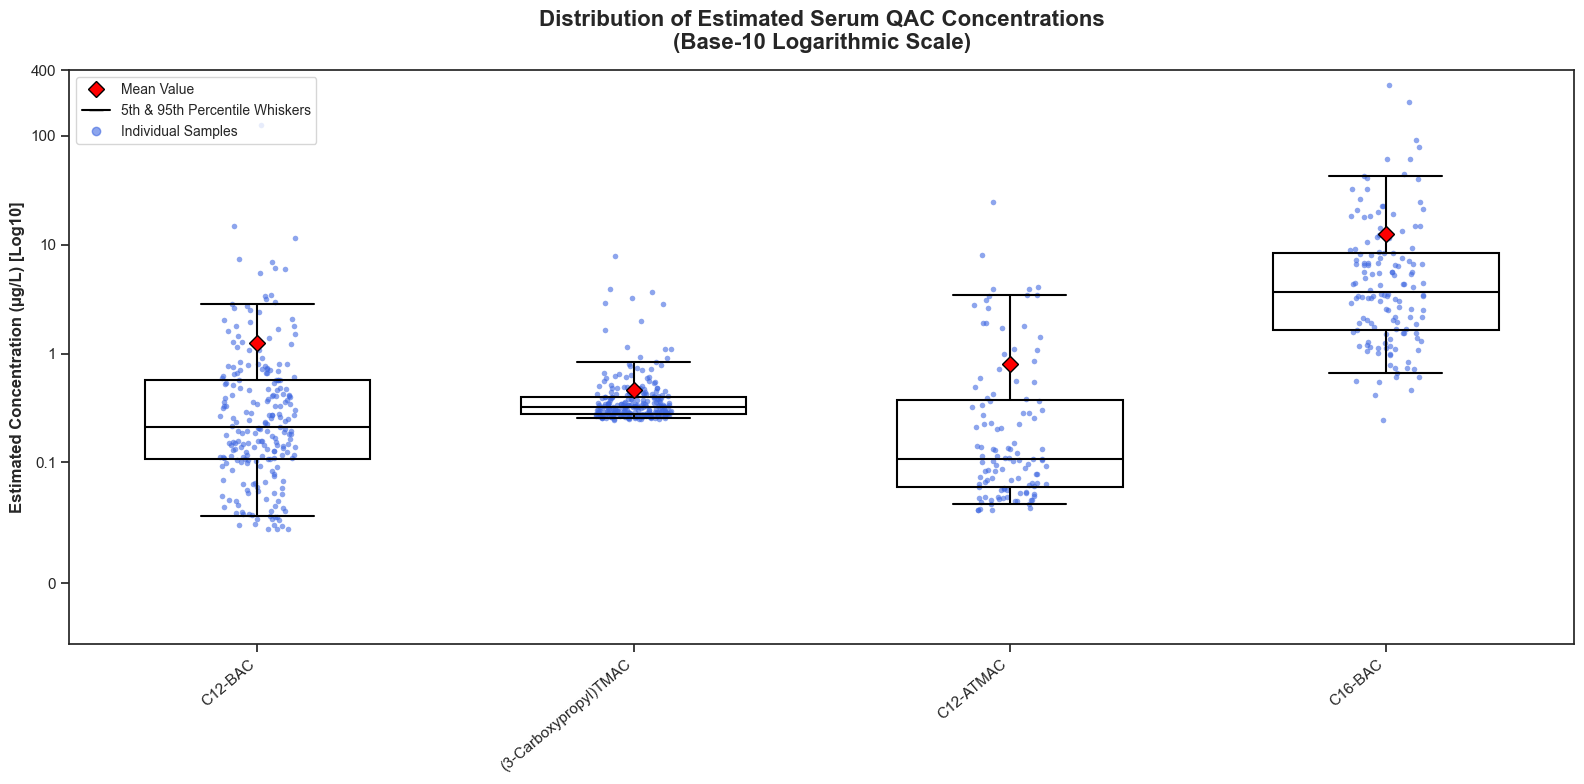

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# =====================================================================
# 1. Prepare Data for a Single Unified Plot
# =====================================================================
plot_df = est_conc_df.copy()

# Map DTXSIDs to Compound Names
name_map = {dtx: calib_models_dtxsid.get(dtx, {}).get('name', dtx) for dtx in plot_df.index}

# Shorten some extremely long names so the x-axis stays readable
clean_names = {
    'DTXSID3041665': 'C16-BAC',
    'DTXSID2040787': 'C12-BAC',
    'DTXSID00978073': '(3-Carboxypropyl)TMAC', 
    'DTXSID1026900': 'C12-ATMAC'
}

# Apply the names and explicitly name the index to prevent melt errors
plot_df.index = plot_df.index.map(lambda x: clean_names.get(x, name_map.get(x, x)))
plot_df.index.name = 'Compound Name'

# Melt into Long Format for Seaborn 
plot_df = plot_df.reset_index().melt(id_vars='Compound Name', var_name='Sample', value_name='Concentration')
plot_df = plot_df.dropna(subset=['Concentration'])

# =====================================================================
# 2. Draw the Unified Plot
# =====================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="ticks")

# 2A. Boxplot (5th & 95th Percentiles)
# We set facecolor to 'none' to make the boxes entirely transparent!
sns.boxplot(
    data=plot_df, x='Compound Name', y='Concentration', 
    whis=[5, 95], showmeans=True, showfliers=False, width=0.6, zorder=2,
    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5},
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'color': 'black', 'linewidth': 1.5},
    capprops={'color': 'black', 'linewidth': 1.5},
    meanprops={"marker":"D", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":8}
)

# 2B. Scatter Overlay
sns.stripplot(
    data=plot_df, x='Compound Name', y='Concentration', 
    size=4, color="royalblue", alpha=0.6, jitter=True, zorder=1
)

# =====================================================================
# 3. Y-Axis Scaling (0.1 to 400)
# =====================================================================
# We use symlog to preserve the 0.0 values
plt.yscale('symlog', linthresh=0.1, base=10)

# Set the limits. -0.05 at the bottom prevents 0.0 dots from being cut in half
plt.ylim(-0.05, 400)

# Explicitly set the ticks to perfectly match powers of 10 up to 400
plt.yticks([0, 0.1, 1, 10, 100, 400], labels=['0', '0.1', '1', '10', '100', '400'])


# =====================================================================
# 4. Formatting & Labels
# =====================================================================
plt.title('Distribution of Estimated Serum QAC Concentrations\n(Base-10 Logarithmic Scale)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Estimated Concentration (µg/L) [Log10]', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=40, ha='right', fontsize=11)

# Custom legend
mean_legend = mlines.Line2D([], [], color='red', marker='D', linestyle='None',
                          markersize=8, markeredgecolor='black', label='Mean Value')
whisker_legend = mlines.Line2D([], [], color='black', marker='_', linestyle='-',
                          markersize=10, label='5th & 95th Percentile Whiskers')
scatter_legend = mlines.Line2D([], [], color='royalblue', marker='o', linestyle='None',
                          markersize=6, alpha=0.6, label='Individual Samples')

plt.legend(handles=[mean_legend, whisker_legend, scatter_legend], loc='upper left', frameon=True, fontsize=10)

# Adjust layout and save
plt.tight_layout()
plt.savefig('Estimated_Concentrations_All_Log10_TransparentBox.png', dpi=300, bbox_inches='tight')

print("✅ Unified Plot saved successfully as 'Estimated_Concentrations_All_Log10_TransparentBox.png'")
plt.show()

In [136]:
# 1. Automatically grab the columns from your previously generated summary table!
cols_needed = ['Min', '5th Percentile', 'Median (50th)', 'Mean', '95th Percentile', 'Max']
df_exposure = summary_stats_df.set_index('Compound Name')[cols_needed].copy()

# 2. Calculate the Cumulative Mixture Burden (Summing all QACs)
df_exposure.loc['CUMULATIVE MIXTURE'] = df_exposure.sum()

# 3. Define the In Vitro Toxicity Threshold (AC50 / IC50) in ug/L
tox_threshold = 1000 # Conservative 1000 ug/L threshold for all QACs and the mixture

# 4. Calculate the Margin of Exposure (MOE)
moe_df = pd.DataFrame(index=df_exposure.index)

for col in cols_needed:
    # Safely replace 0 with NaN to prevent ZeroDivisionError, divide, then fill with Infinity
    safe_denominator = df_exposure[col].replace(0, np.nan)
    
    moe_df[col] = tox_threshold / safe_denominator
    
    # Any value that was divided by NaN is now NaN. Replace it with Infinity (No Risk)
    moe_df[col] = moe_df[col].fillna(np.inf)

# 5. Format the output to highlight risk
def format_moe(val):
    if np.isinf(val):
        return "No Risk"
    elif val < 100:
        return f"⚠️ {val:.1f} (Risk)"
    else:
        return f"{val:.1f} (Safe)"

# applymap is deprecated in newer Pandas, using map for whole dataframe safely
moe_formatted = moe_df.map(format_moe) if hasattr(moe_df, 'map') else moe_df.applymap(format_moe)

print("\n--- Margin of Exposure (MOE) Risk Assessment ---")
print("* MOE > 100 = Safe | MOE < 100 = Potential Health Risk (Level of Concern)")
print("* Assumes mixture Dose-Additivity (Hazard Index method)")
print(tabulate.tabulate(moe_formatted, headers='keys', tablefmt='psql'))


--- Margin of Exposure (MOE) Risk Assessment ---
* MOE > 100 = Safe | MOE < 100 = Potential Health Risk (Level of Concern)
* Assumes mixture Dose-Additivity (Hazard Index method)
+---------------------------------------------+----------------+------------------+-----------------+----------------+-------------------+----------------+
| Compound Name                               | Min            | 5th Percentile   | Median (50th)   | Mean           | 95th Percentile   | Max            |
|---------------------------------------------+----------------+------------------+-----------------+----------------+-------------------+----------------|
| nan                                         | No Risk        | No Risk          | No Risk         | No Risk        | No Risk           | No Risk        |
| C12-BAC                                     | 22350.3 (Safe) | 18120.4 (Safe)   | 4777.5 (Safe)   | 795.0 (Safe)   | 337.5 (Safe)      | ⚠️ 8.0 (Risk)  |
| nan                                   

In [ ]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
import warnings


#semi-quantification for association studyies
import pandas as pd
OUTPUT_DIR = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC'
est_conc_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'estimated_concentration_byCalcurve_26March.csv'))

#drop nan rows
bh_cols = [col for col in est_conc_df.columns if col.startswith('BH')]
est_conc_df = est_conc_df.dropna(subset = bh_cols, how = 'all')
#Replace remaining NaN values with 0
est_conc_df = est_conc_df.fillna(0)
dtxsid = est_conc_df['DTXSID'].to_list()
est_conc_df = est_conc_df.set_index('DTXSID')

#perform spearman correlation analysis to find the pattern between the QA compounds


In [ ]:
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
import warnings


#semi-quantification for association studyies
import pandas as pd
OUTPUT_DIR = r'D:\UCSF_postdoc_topic\Collaboration\prenatal_exposure_QAC'
est_conc_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'estimated_concentration_byCalcurve_26March.csv'))

#drop nan rows
bh_cols = [col for col in est_conc_df.columns if col.startswith('BH')]
est_conc_df = est_conc_df.dropna(subset = bh_cols, how = 'all')
#Replace remaining NaN values with 0
est_conc_df = est_conc_df.fillna(0)
dtxsid = est_conc_df['DTXSID'].to_list()
est_conc_df = est_conc_df.set_index('DTXSID')

#import pregnancy outcomes-participant ID
sample_name = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_first_400/demographics_data/REVEAL_sample_name_positive_with_participantID.csv")
sample_ids = sample_name['Participant_ID'].dropna().astype(int).unique()
sample_ids = sample_ids.astype(str).tolist()
num_sample_cols = est_conc_df.shape[1]
est_conc_df.columns = list(sample_ids[:num_sample_cols])
est_conc_df['ID'] = dtxsid


# --- 7. Melt to Long Format for Downstream Testing ---
df_sparse_long = est_conc_df.melt(
    id_vars='ID', 
    var_name='ppt_id', 
    value_name='peak_area')

# Ensure ppt_id is a string so it merges perfectly with demogra_data
df_sparse_long['ppt_id'] = df_sparse_long['ppt_id'].astype(str)
demogra_data_clean = demogra_data.loc[:, ~demogra_data.columns.duplicated()].copy()
demogra_data_clean['ppt_id'] = demogra_data_clean['ppt_id'].astype(str)

# Merge clinical outcomes
df_sparse_long = df_sparse_long.merge(demogra_data_clean, on='ppt_id', how='left')

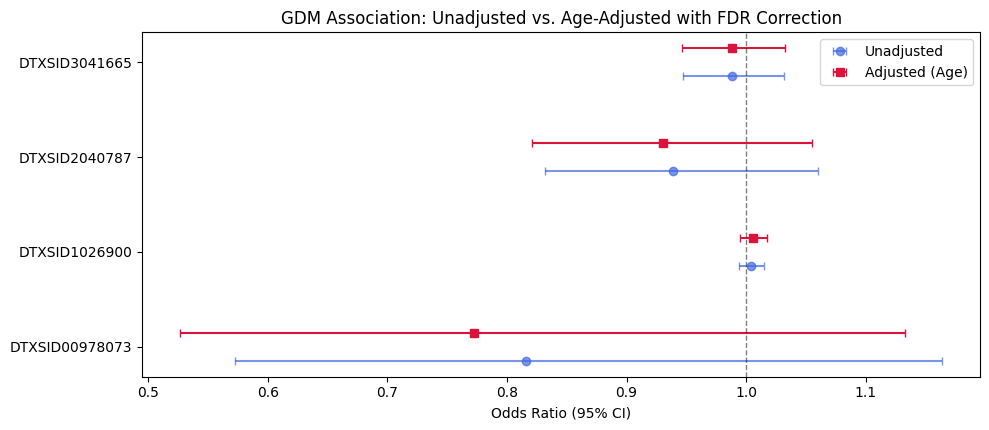

       feature_id  OR_unadj  p_unadj_bh    OR_adj  p_adj_bh
0  DTXSID00978073  0.816342    0.596121  0.772583  0.380586
1   DTXSID1026900  1.004049    0.596121  1.005993  0.380586
2   DTXSID2040787  0.938842    0.596121  0.930460  0.380586
3   DTXSID3041665  0.988537    0.596121  0.988435  0.599219


In [78]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import PerfectSeparationError

# # Load data
# df = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_topics/REVEAL_200samples_analysis/demographic_data/temp_files/demogra_data_peak_GDM.csv")
# df['GDM_bin'] = df['GDM_diag'].map({'Non-GDM': 0, 'GDM': 1})

# # Ordinal encode Edu
# edu_order = ['Highschool/less', 'College', 'Post_grad']
# df['Edu_code'] = pd.Categorical(df['Edu'], categories=edu_order, ordered=True).codes

# # Identify features
# feature_cols = [c for c in df.columns if '_' in c and all(p.replace('.', '',1).isdigit() for p in c.split('_'))]

# results = []
# for feat in feature_cols:
#     sub = df[['GDM_bin','Edu_code','age_dlvry_mr',feat]].dropna().rename(columns={feat:'peak_area'})
#     if sub['GDM_bin'].nunique()<2: continue
#     iqr = sub['peak_area'].quantile(0.75)-sub['peak_area'].quantile(0.25)
#     if iqr==0: continue
#     sub['peak_iqr'] = sub['peak_area']/iqr
    
#     # Unadjusted
#     mu = smf.logit("GDM_bin ~ peak_iqr", data=sub).fit(disp=False, method='bfgs')
#     cu, iu, pu = mu.params['peak_iqr'], mu.conf_int().loc['peak_iqr'], mu.pvalues['peak_iqr']
    
#     # Adjusted with bfgs
#     try:
#         ma = smf.logit("GDM_bin ~ peak_iqr + Edu_code + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
#         ca, ia, pa = ma.params['peak_iqr'], ma.conf_int().loc['peak_iqr'], ma.pvalues['peak_iqr']
#     except PerfectSeparationError:
#         ca = pa = np.nan; ia = [np.nan, np.nan]
    
#     results.append({
#         'feature_id': feat,
#         'OR_unadj': np.exp(cu),
#         'CI2.5_unadj': np.exp(iu[0]),
#         'CI97.5_unadj': np.exp(iu[1]),
#         'p_unadj': pu,
#         'OR_adj': np.exp(ca) if not np.isnan(ca) else np.nan,
#         'CI2.5_adj': np.exp(ia[0]) if not np.isnan(ia[0]) else np.nan,
#         'CI97.5_adj': np.exp(ia[1]) if not np.isnan(ia[1]) else np.nan,
#         'p_adj': pa
#     })

# results_df = pd.DataFrame(results)

# # --- 3) Display results table ---
# print("GDM_diagnosis Logistic Regression Results")
# print(results_df.to_string(index=False))

# # --- 4) Visualization: forest plot ---
# y = np.arange(len(results_df))
# plt.figure(figsize=(8, 5))
# # unadjusted
# plt.errorbar(results_df['OR_unadj'], y,
#              xerr=[results_df['OR_unadj']-results_df['CI2.5_unadj'], 
#                    results_df['CI97.5_unadj']-results_df['OR_unadj']],
#              fmt='o', label='Unadjusted')
# # adjusted
# plt.errorbar(results_df['OR_adj'], y,
#              xerr=[results_df['OR_adj']-results_df['CI2.5_adj'], 
#                    results_df['CI97.5_adj']-results_df['OR_adj']],
#              fmt='s', label='Adjusted')
# plt.axvline(1, color='gray', linestyle='--')
# plt.yticks(y, results_df['feature_id'])
# plt.xlabel('Odds Ratio (95% CI)')
# plt.title('GDM_diagnosis: Unadjusted vs. Adjusted OR per IQR Increase')
# plt.legend()
# plt.tight_layout()
# plt.show()


# Load data
# df = pd.read_csv("D:/UCSF_postdoc_topic/REVEAL_topics/REVEAL_200samples_analysis/demographic_data/temp_files/demogra_data_peak_GDM.csv")
# Create the wide peak area table
# We index by ppt_id to keep one row per participant
df_wide_peaks = df_sparse_long.pivot(index='ppt_id', columns='ID', values='peak_area')

# Get participant demographics (dropping duplicates to get one row per person)
df_demogra = df_sparse_long[['ppt_id', 'GDM_diag', 'age_dlvry_mr', 'Terms', 'Race']].drop_duplicates(subset='ppt_id')
df_demogra = df_demogra.set_index('ppt_id')

# Combine them into one wide analysis dataframe
df_analysis = pd.concat([df_demogra, df_wide_peaks], axis=1)

# Encode outcome
df_analysis['GDM_bin'] = df_analysis['GDM_diag'].map({'Non-GDM': 0, 'GDM': 1})

# Define your features (the chemical IDs)
feature_cols = df_wide_peaks.columns.tolist()

results = []
for feat in feature_cols:
    sub = df_analysis[['GDM_bin','age_dlvry_mr',feat]].dropna().rename(columns={feat:'peak_area'})
    if sub['GDM_bin'].nunique()<2: continue
    iqr = sub['peak_area'].quantile(0.75)-sub['peak_area'].quantile(0.25)
    if iqr==0: continue
    sub['peak_iqr'] = sub['peak_area']/iqr
    
    # Unadjusted
    mu = smf.logit("GDM_bin ~ peak_iqr", data=sub).fit(disp=False, method='bfgs')
    cu, iu, pu = mu.params['peak_iqr'], mu.conf_int().loc['peak_iqr'], mu.pvalues['peak_iqr']
    
    # Adjusted with bfgs
    try:
        ma = smf.logit("GDM_bin ~ peak_iqr + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
        ca, ia, pa = ma.params['peak_iqr'], ma.conf_int().loc['peak_iqr'], ma.pvalues['peak_iqr']
    except PerfectSeparationError:
        ca = pa = np.nan; ia = [np.nan, np.nan]
    
    results.append({
        'feature_id': feat,
        'OR_unadj': np.exp(cu),
        'CI2.5_unadj': np.exp(iu[0]),
        'CI97.5_unadj': np.exp(iu[1]),
        'p_unadj': pu,
        'OR_adj': np.exp(ca) if not np.isnan(ca) else np.nan,
        'CI2.5_adj': np.exp(ia[0]) if not np.isnan(ia[0]) else np.nan,
        'CI97.5_adj': np.exp(ia[1]) if not np.isnan(ia[1]) else np.nan,
        'p_adj': pa
    })

results_df = pd.DataFrame(results)

from statsmodels.stats.multitest import multipletests

# 1. Apply BH correction for BOTH sets of p-values
if not results_df.empty:
    # Correct Unadjusted p-values
    results_df['p_unadj_bh'] = multipletests(results_df['p_unadj'], method='fdr_bh')[1]
    
    # Correct Adjusted p-values (handling potential NaNs)
    mask = results_df['p_adj'].notna()
    results_df.loc[mask, 'p_adj_bh'] = multipletests(results_df.loc[mask, 'p_adj'], method='fdr_bh')[1]

# 2. Sort by the Adjusted BH p-value to keep things organized
results_df = results_df.sort_values('p_adj_bh')

# --- Visualization: Dual Forest Plot ---
plt.figure(figsize=(10, len(results_df) * 0.6 + 2))
y = np.arange(len(results_df))

# Plot Unadjusted ORs (Blue Circles)
plt.errorbar(results_df['OR_unadj'], y - 0.15,
             xerr=[results_df['OR_unadj'] - results_df['CI2.5_unadj'], 
                   results_df['CI97.5_unadj'] - results_df['OR_unadj']],
             fmt='o', color='royalblue', label='Unadjusted', capsize=3, alpha=0.7)

# Plot Adjusted ORs (Red Squares)
plt.errorbar(results_df['OR_adj'], y + 0.15,
             xerr=[results_df['OR_adj'] - results_df['CI2.5_adj'], 
                   results_df['CI97.5_adj'] - results_df['OR_adj']],
             fmt='s', color='crimson', label='Adjusted (Age)', capsize=3)

# Highlight significance (Star markers for BH-significant results)
# We highlight if the Adjusted BH p-value < 0.05
sig_mask = results_df['p_adj_bh'] < 0.05
if sig_mask.any():
    plt.scatter(results_df.loc[sig_mask, 'OR_adj'], y[sig_mask] + 0.15, 
                marker='*', color='gold', s=100, edgecolors='black', 
                label='FDR Sig (p_adj_bh < 0.05)', zorder=5)

plt.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y, results_df['feature_id'])
plt.xlabel('Odds Ratio (95% CI)')
plt.title('GDM Association: Unadjusted vs. Age-Adjusted with FDR Correction')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Display the top 10 comparison
print(results_df[['feature_id', 'OR_unadj', 'p_unadj_bh', 'OR_adj', 'p_adj_bh']].head(10))


# # --- 3) Display results table ---
# print("GDM_diagnosis Logistic Regression Results")
# print(results_df.to_string(index=False))

# # --- 4) Visualization: forest plot ---
# y = np.arange(len(results_df))
# plt.figure(figsize=(8, 5))
# # unadjusted
# plt.errorbar(results_df['OR_unadj'], y,
#              xerr=[results_df['OR_unadj']-results_df['CI2.5_unadj'], 
#                    results_df['CI97.5_unadj']-results_df['OR_unadj']],
#              fmt='o', label='Unadjusted')
# # adjusted
# plt.errorbar(results_df['OR_adj'], y,
#              xerr=[results_df['OR_adj']-results_df['CI2.5_adj'], 
#                    results_df['CI97.5_adj']-results_df['OR_adj']],
#              fmt='s', label='Adjusted')
# plt.axvline(1, color='gray', linestyle='--')
# plt.yticks(y, results_df['feature_id'])
# plt.xlabel('Odds Ratio (95% CI)')
# plt.title('GDM_diagnosis: Unadjusted vs. Adjusted OR per IQR Increase')
# plt.legend()
# plt.tight_layout()
# plt.show()


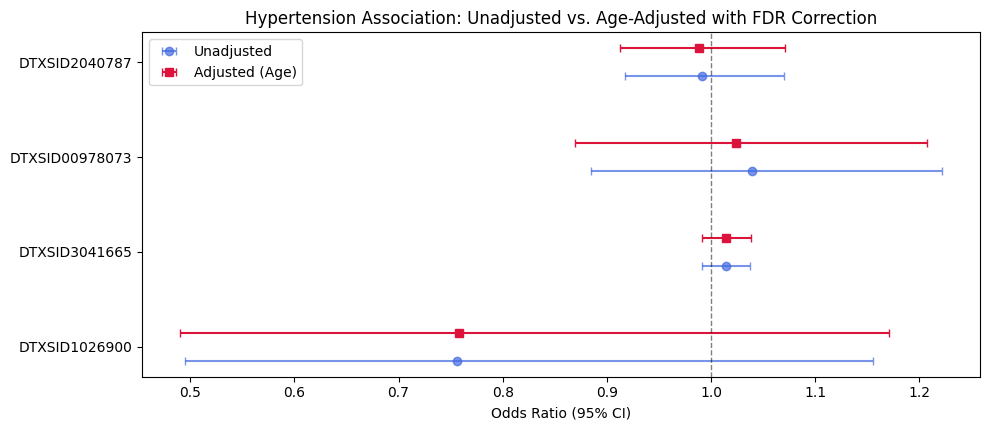

       feature_id  OR_unadj  p_unadj_bh    OR_adj  p_adj_bh
1   DTXSID1026900  0.756192    0.436864  0.757706  0.430442
3   DTXSID3041665  1.014353    0.436864  1.014630  0.430442
0  DTXSID00978073  1.039764    0.814038  1.024293  0.781223
2   DTXSID2040787  0.990850    0.814038  0.988736  0.781223


In [83]:
###hepertension
df_wide_peaks = df_sparse_long.pivot(index='ppt_id', columns='ID', values='peak_area')

# Get participant demographics (dropping duplicates to get one row per person)
df_demogra = df_sparse_long[['ppt_id', 'GDM_diag', 'age_dlvry_mr', 'Terms', 'Race','hypertension','preclmps_mr']].drop_duplicates(subset='ppt_id')
df_demogra = df_demogra.set_index('ppt_id')

# Combine them into one wide analysis dataframe
df_analysis = pd.concat([df_demogra, df_wide_peaks], axis=1)

# Encode outcome
df_analysis['HTN_bin'] = df_analysis['hypertension'].map({'non-hypertension': 0, 'hypertension': 1})
df_analysis['Term_bin'] = df_analysis['Terms'].map({'full_term': 0, 'preterm': 1})
df_analysis['preclampsia_bin'] = df_analysis['preclmps_mr'].map({'non-preclampsia': 0, 'preclampsia': 1})


# Define your features (the chemical IDs)
feature_cols = df_wide_peaks.columns.tolist()

# --- 2) Run unadjusted & adjusted logistic regressions ---
results = []
for feat in feature_cols:
    # sub = df[['HTN_bin', 'Edu_code', 'age_dlvry_mr', feat]].dropna().copy()
    sub = df_analysis[['HTN_bin', 'age_dlvry_mr', feat]].dropna().copy()
    sub.rename(columns={feat: 'peak_area'}, inplace=True)
    if sub['HTN_bin'].nunique() < 2:
        continue
    # scale by IQR
    iqr = sub['peak_area'].quantile(0.75) - sub['peak_area'].quantile(0.25)
    if iqr == 0:
        continue
    sub['peak_iqr'] = sub['peak_area'] / iqr

    # Unadjusted model
    mu = smf.logit("HTN_bin ~ peak_iqr", data=sub).fit(disp=False, method='bfgs')
    cu, iu, pu = mu.params['peak_iqr'], mu.conf_int().loc['peak_iqr'], mu.pvalues['peak_iqr']

    # Adjusted model (Edu + age)
    # ma = smf.logit("HTN_bin ~ peak_iqr + Edu_code + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ma = smf.logit("HTN_bin ~ peak_iqr + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ca, ia, pa = ma.params['peak_iqr'], ma.conf_int().loc['peak_iqr'], ma.pvalues['peak_iqr']

    results.append({
        'feature_id':     feat,
        'OR_unadj':       np.exp(cu),
        'CI2.5_unadj':    np.exp(iu[0]),
        'CI97.5_unadj':   np.exp(iu[1]),
        'p_unadj':        pu,
        'OR_adj':         np.exp(ca),
        'CI2.5_adj':      np.exp(ia[0]),
        'CI97.5_adj':     np.exp(ia[1]),
        'p_adj':          pa
    })

results_df = pd.DataFrame(results)

# 1. Apply BH correction for BOTH sets of p-values
if not results_df.empty:
    # Correct Unadjusted p-values
    results_df['p_unadj_bh'] = multipletests(results_df['p_unadj'], method='fdr_bh')[1]
    
    # Correct Adjusted p-values (handling potential NaNs)
    mask = results_df['p_adj'].notna()
    results_df.loc[mask, 'p_adj_bh'] = multipletests(results_df.loc[mask, 'p_adj'], method='fdr_bh')[1]

# 2. Sort by the Adjusted BH p-value to keep things organized
results_df = results_df.sort_values('p_adj_bh')

# --- Visualization: Dual Forest Plot ---
plt.figure(figsize=(10, len(results_df) * 0.6 + 2))
y = np.arange(len(results_df))

# Plot Unadjusted ORs (Blue Circles)
plt.errorbar(results_df['OR_unadj'], y - 0.15,
             xerr=[results_df['OR_unadj'] - results_df['CI2.5_unadj'], 
                   results_df['CI97.5_unadj'] - results_df['OR_unadj']],
             fmt='o', color='royalblue', label='Unadjusted', capsize=3, alpha=0.7)

# Plot Adjusted ORs (Red Squares)
plt.errorbar(results_df['OR_adj'], y + 0.15,
             xerr=[results_df['OR_adj'] - results_df['CI2.5_adj'], 
                   results_df['CI97.5_adj'] - results_df['OR_adj']],
             fmt='s', color='crimson', label='Adjusted (Age)', capsize=3)

# Highlight significance (Star markers for BH-significant results)
# We highlight if the Adjusted BH p-value < 0.05
sig_mask = results_df['p_adj_bh'] < 0.05
if sig_mask.any():
    plt.scatter(results_df.loc[sig_mask, 'OR_adj'], y[sig_mask] + 0.15, 
                marker='*', color='gold', s=100, edgecolors='black', 
                label='FDR Sig (p_adj_bh < 0.05)', zorder=5)

plt.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y, results_df['feature_id'])
plt.xlabel('Odds Ratio (95% CI)')
plt.title('Hypertension Association: Unadjusted vs. Age-Adjusted with FDR Correction')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Display the top 10 comparison
print(results_df[['feature_id', 'OR_unadj', 'p_unadj_bh', 'OR_adj', 'p_adj_bh']].head(10))


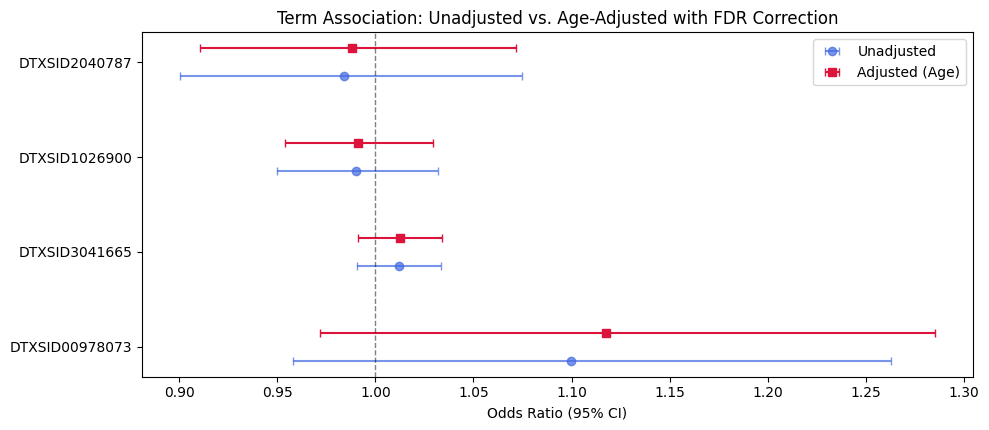

       feature_id  OR_unadj  p_unadj_bh    OR_adj  p_adj_bh
0  DTXSID00978073  1.099864    0.550497  1.117609  0.475837
3   DTXSID3041665  1.011819    0.550497  1.012355  0.507798
1   DTXSID1026900  0.989918    0.718411  0.991036  0.770865
2   DTXSID2040787  0.983840    0.718411  0.987966  0.770865


In [86]:
results = []
for feat in feature_cols:
    # sub = df[['HTN_bin', 'Edu_code', 'age_dlvry_mr', feat]].dropna().copy()
    sub = df_analysis[['Term_bin', 'age_dlvry_mr', feat]].dropna().copy()
    sub.rename(columns={feat: 'peak_area'}, inplace=True)
    if sub['Term_bin'].nunique() < 2:
        continue
    # scale by IQR
    iqr = sub['peak_area'].quantile(0.75) - sub['peak_area'].quantile(0.25)
    if iqr == 0:
        continue
    sub['peak_iqr'] = sub['peak_area'] / iqr

    # Unadjusted model
    mu = smf.logit("Term_bin ~ peak_iqr", data=sub).fit(disp=False, method='bfgs')
    cu, iu, pu = mu.params['peak_iqr'], mu.conf_int().loc['peak_iqr'], mu.pvalues['peak_iqr']

    # Adjusted model (Edu + age)
    # ma = smf.logit("HTN_bin ~ peak_iqr + Edu_code + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ma = smf.logit("Term_bin ~ peak_iqr + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ca, ia, pa = ma.params['peak_iqr'], ma.conf_int().loc['peak_iqr'], ma.pvalues['peak_iqr']

    results.append({
        'feature_id':     feat,
        'OR_unadj':       np.exp(cu),
        'CI2.5_unadj':    np.exp(iu[0]),
        'CI97.5_unadj':   np.exp(iu[1]),
        'p_unadj':        pu,
        'OR_adj':         np.exp(ca),
        'CI2.5_adj':      np.exp(ia[0]),
        'CI97.5_adj':     np.exp(ia[1]),
        'p_adj':          pa
    })

results_df = pd.DataFrame(results)

# 1. Apply BH correction for BOTH sets of p-values
if not results_df.empty:
    # Correct Unadjusted p-values
    results_df['p_unadj_bh'] = multipletests(results_df['p_unadj'], method='fdr_bh')[1]
    
    # Correct Adjusted p-values (handling potential NaNs)
    mask = results_df['p_adj'].notna()
    results_df.loc[mask, 'p_adj_bh'] = multipletests(results_df.loc[mask, 'p_adj'], method='fdr_bh')[1]

# 2. Sort by the Adjusted BH p-value to keep things organized
results_df = results_df.sort_values('p_adj_bh')

# --- Visualization: Dual Forest Plot ---
plt.figure(figsize=(10, len(results_df) * 0.6 + 2))
y = np.arange(len(results_df))

# Plot Unadjusted ORs (Blue Circles)
plt.errorbar(results_df['OR_unadj'], y - 0.15,
             xerr=[results_df['OR_unadj'] - results_df['CI2.5_unadj'], 
                   results_df['CI97.5_unadj'] - results_df['OR_unadj']],
             fmt='o', color='royalblue', label='Unadjusted', capsize=3, alpha=0.7)

# Plot Adjusted ORs (Red Squares)
plt.errorbar(results_df['OR_adj'], y + 0.15,
             xerr=[results_df['OR_adj'] - results_df['CI2.5_adj'], 
                   results_df['CI97.5_adj'] - results_df['OR_adj']],
             fmt='s', color='crimson', label='Adjusted (Age)', capsize=3)

# Highlight significance (Star markers for BH-significant results)
# We highlight if the Adjusted BH p-value < 0.05
sig_mask = results_df['p_adj_bh'] < 0.05
if sig_mask.any():
    plt.scatter(results_df.loc[sig_mask, 'OR_adj'], y[sig_mask] + 0.15, 
                marker='*', color='gold', s=100, edgecolors='black', 
                label='FDR Sig (p_adj_bh < 0.05)', zorder=5)

plt.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y, results_df['feature_id'])
plt.xlabel('Odds Ratio (95% CI)')
plt.title('Term Association: Unadjusted vs. Age-Adjusted with FDR Correction')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Display the top 10 comparison
print(results_df[['feature_id', 'OR_unadj', 'p_unadj_bh', 'OR_adj', 'p_adj_bh']].head(10))


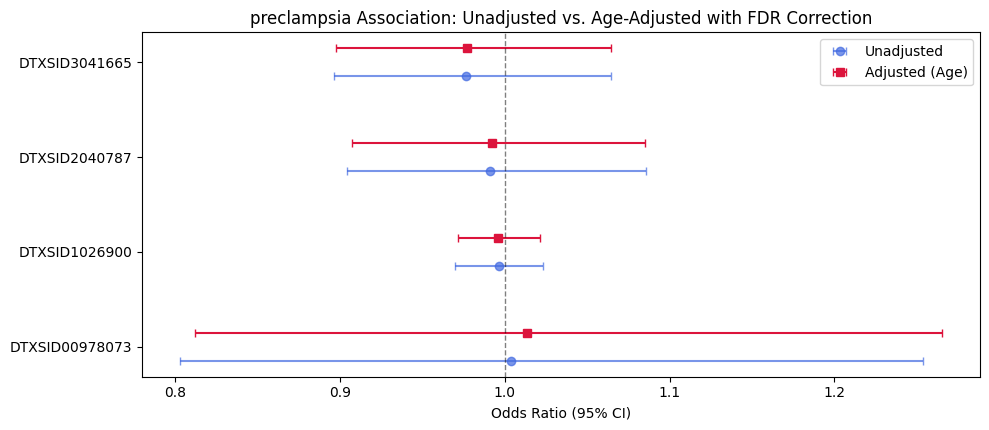

       feature_id  OR_unadj  p_unadj_bh    OR_adj  p_adj_bh
0  DTXSID00978073  1.003531    0.975268  1.013640  0.904655
1   DTXSID1026900  0.996343    0.975268  0.995965  0.904655
2   DTXSID2040787  0.990906    0.975268  0.992342  0.904655
3   DTXSID3041665  0.976723    0.975268  0.977177  0.904655


In [85]:
results = []
for feat in feature_cols:
    # sub = df[['HTN_bin', 'Edu_code', 'age_dlvry_mr', feat]].dropna().copy()
    sub = df_analysis[['preclampsia_bin', 'age_dlvry_mr', feat]].dropna().copy()
    sub.rename(columns={feat: 'peak_area'}, inplace=True)
    if sub['preclampsia_bin'].nunique() < 2:
        continue
    # scale by IQR
    iqr = sub['peak_area'].quantile(0.75) - sub['peak_area'].quantile(0.25)
    if iqr == 0:
        continue
    sub['peak_iqr'] = sub['peak_area'] / iqr

    # Unadjusted model
    mu = smf.logit("preclampsia_bin ~ peak_iqr", data=sub).fit(disp=False, method='bfgs')
    cu, iu, pu = mu.params['peak_iqr'], mu.conf_int().loc['peak_iqr'], mu.pvalues['peak_iqr']

    # Adjusted model (Edu + age)
    # ma = smf.logit("HTN_bin ~ peak_iqr + Edu_code + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ma = smf.logit("preclampsia_bin ~ peak_iqr + age_dlvry_mr", data=sub).fit(disp=False, method='bfgs')
    ca, ia, pa = ma.params['peak_iqr'], ma.conf_int().loc['peak_iqr'], ma.pvalues['peak_iqr']

    results.append({
        'feature_id':     feat,
        'OR_unadj':       np.exp(cu),
        'CI2.5_unadj':    np.exp(iu[0]),
        'CI97.5_unadj':   np.exp(iu[1]),
        'p_unadj':        pu,
        'OR_adj':         np.exp(ca),
        'CI2.5_adj':      np.exp(ia[0]),
        'CI97.5_adj':     np.exp(ia[1]),
        'p_adj':          pa
    })

results_df = pd.DataFrame(results)

# 1. Apply BH correction for BOTH sets of p-values
if not results_df.empty:
    # Correct Unadjusted p-values
    results_df['p_unadj_bh'] = multipletests(results_df['p_unadj'], method='fdr_bh')[1]
    
    # Correct Adjusted p-values (handling potential NaNs)
    mask = results_df['p_adj'].notna()
    results_df.loc[mask, 'p_adj_bh'] = multipletests(results_df.loc[mask, 'p_adj'], method='fdr_bh')[1]

# 2. Sort by the Adjusted BH p-value to keep things organized
results_df = results_df.sort_values('p_adj_bh')

# --- Visualization: Dual Forest Plot ---
plt.figure(figsize=(10, len(results_df) * 0.6 + 2))
y = np.arange(len(results_df))

# Plot Unadjusted ORs (Blue Circles)
plt.errorbar(results_df['OR_unadj'], y - 0.15,
             xerr=[results_df['OR_unadj'] - results_df['CI2.5_unadj'], 
                   results_df['CI97.5_unadj'] - results_df['OR_unadj']],
             fmt='o', color='royalblue', label='Unadjusted', capsize=3, alpha=0.7)

# Plot Adjusted ORs (Red Squares)
plt.errorbar(results_df['OR_adj'], y + 0.15,
             xerr=[results_df['OR_adj'] - results_df['CI2.5_adj'], 
                   results_df['CI97.5_adj'] - results_df['OR_adj']],
             fmt='s', color='crimson', label='Adjusted (Age)', capsize=3)

# Highlight significance (Star markers for BH-significant results)
# We highlight if the Adjusted BH p-value < 0.05
sig_mask = results_df['p_adj_bh'] < 0.05
if sig_mask.any():
    plt.scatter(results_df.loc[sig_mask, 'OR_adj'], y[sig_mask] + 0.15, 
                marker='*', color='gold', s=100, edgecolors='black', 
                label='FDR Sig (p_adj_bh < 0.05)', zorder=5)

plt.axvline(1, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y, results_df['feature_id'])
plt.xlabel('Odds Ratio (95% CI)')
plt.title('preclampsia Association: Unadjusted vs. Age-Adjusted with FDR Correction')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Display the top 10 comparison
print(results_df[['feature_id', 'OR_unadj', 'p_unadj_bh', 'OR_adj', 'p_adj_bh']].head(10))

In [87]:
Chem.MolToInchiKey(Chem.MolFromSmiles('C[N+](C)(C)CCCC([O-])=O'))

'JHPNVNIEXXLNTR-UHFFFAOYSA-N'

In [ ]:
# import pandas as pd
# import numpy as np
# import tabulate

# # Assuming valid_compounds, full_x, restricted_x etc. are already loaded
# lod_results = []

# for index, row in valid_compounds.iterrows():
#     dtxsid = str(row['DTXSID']).strip()
#     name = row['Name']
    
#     # Assign the correct concentration range based on previous logic
#     if dtxsid in restricted_25_dtxsids:
#         curr_cols = restricted_25_conc_cols; curr_x = restricted_25_x
#     elif dtxsid in restricted_10_dtxsids:
#         curr_cols = restricted_10_conc_cols; curr_x = restricted_10_x
#     else:
#         curr_cols = full_conc_cols; curr_x = full_x
        
#     raw_areas = row[curr_cols].values.astype(float)
#     tpp_areas = tpp_row[curr_cols].values.astype(float)
#     y_calib = raw_areas / tpp_areas
    
#     x_flat = curr_x.flatten()
    
#     # Calculate 1/x weights
#     weights = np.where(x_flat == 0, 1.0, 1.0 / x_flat)
#     w_poly = np.sqrt(weights)
    
#     # Fit Linear Model to get the Slope (S)
#     coeffs_lin = np.polyfit(x_flat, y_calib, deg=1, w=w_poly)
#     slope = coeffs_lin[0]
    
#     # Predict y values to calculate the residuals
#     y_pred = np.polyval(coeffs_lin, x_flat)
    
#     # Calculate Residual Standard Error (Sy.x) - This is our Sigma (σ)
#     residuals = y_calib - y_pred
#     rss = np.sum(residuals**2)
#     degrees_of_freedom = len(x_flat) - 2
    
#     if degrees_of_freedom > 0:
#         s_yx = np.sqrt(rss / degrees_of_freedom)
#     else:
#         # Cannot calculate variance with 2 or fewer points
#         s_yx = np.nan 
        
#     # Calculate LOD (3.3 * σ / S) and LOQ (10 * σ / S)
#     if slope > 0 and not np.isnan(s_yx):
#         lod = (3.3 * s_yx) / slope
#         loq = (10.0 * s_yx) / slope
#     else:
#         lod = np.nan
#         loq = np.nan
        
#     lod_results.append({
#         'Compound Name': name,
#         'DTXSID': dtxsid,
#         'Calibration Points': len(x_flat),
#         'Slope (S)': slope,
#         'Residual Std Err (σ)': s_yx,
#         'Estimated LOD (µg/L)': lod,
#         'Estimated LOQ (µg/L)': loq
#     })

# # Format and output the results as a clean table
# lod_df = pd.DataFrame(lod_results)

# print("\n--- Analytical Limits: LOD and LOQ (Based on 3.3σ/S Method) ---")
# print(tabulate.tabulate(lod_df, headers='keys', tablefmt='psql', floatfmt=".4f"))

# # Optional: Save to CSV
# # lod_df.to_csv('Estimated_LOD_LOQ_QA_Compounds.csv', index=False)


--- Analytical Limits: LOD and LOQ (Based on 3.3σ/S Method) ---
+----+---------------------------------------------+----------------+----------------------+-------------+------------------------+------------------------+------------------------+
|    | Compound Name                               | DTXSID         |   Calibration Points |   Slope (S) |   Residual Std Err (σ) |   Estimated LOD (µg/L) |   Estimated LOQ (µg/L) |
|----+---------------------------------------------+----------------+----------------------+-------------+------------------------+------------------------+------------------------|
|  0 | (3-Carboxypropyl)trimethylammonium chloride | DTXSID00978073 |                    5 |      0.0275 |                 0.2457 |                29.4821 |                89.3397 |
|  1 | C12-ATMAC                                   | DTXSID1026900  |                    5 |      0.1161 |                 0.5771 |                16.4003 |                49.6978 |
|  2 | C12-BAC           

In [ ]:
#convert sample id to ppt id
#using the concentration data for demographic analysis, and do logestic regression analysis for estimation
#for the detection fequency higher than 0.65, 3 compounds = 
